 # TFG: "Feasibility and main features of a survey of low-mass star-forming galaxies at the cosmic noon epoch with the ELT telescope" 
 
by Mario Pérez Racionero

Supervisors: Jesús Gallego Maestro y Cristina Cabello González

In [1]:
import numpy as np
import statistics as stat
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from scipy.stats import kde
import math
from matplotlib.ticker import MaxNLocator
from scipy import stats
from sympy import integrate
from sympy.abc import x
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import Planck13,z_at_value
from sklearn import linear_model

## "Photometric redshifts" catalog version 1 

In [2]:
m0_photoz= np.loadtxt('hlsp_candels_hst_wfc3_egs_multi_v1_photoz-cat.txt', skiprows=14)
print(m0_photoz)

[[1.0000e+00 1.7000e+00 7.1360e+00 ... 2.4400e+00 1.2800e+00 3.3200e+00]
 [2.0000e+00 3.9610e+00 3.8680e+00 ... 4.3200e+00 3.5900e+00 4.4300e+00]
 [3.0000e+00 1.0690e+00 8.5800e-01 ... 1.5400e+00 1.9000e-01 2.2400e+00]
 ...
 [4.1455e+04 1.1070e+00 1.6230e+00 ... 4.9400e+00 3.3000e-01 5.7000e+00]
 [4.1456e+04 1.5860e+00 1.8920e+00 ... 2.2500e+00 4.7000e-01 2.6700e+00]
 [4.1457e+04 2.3350e+00 2.4320e+00 ... 3.3500e+00 2.9000e-01 4.2000e+00]]


## "Photometric redshifts" catalog version 2

In [3]:
m0_photoz21= np.loadtxt('hlsp_candels_hst_wfc3_egs_multi_v2_redshift-cat.txt', skiprows=61,usecols= range(6,7)) #z_spec
m0_photoz22= np.loadtxt('hlsp_candels_hst_wfc3_egs_multi_v2_redshift-cat.txt', skiprows=61,usecols= range(9,57))
m0_photoz23= np.loadtxt('hlsp_candels_hst_wfc3_egs_multi_v2_redshift-cat.txt', skiprows=61,usecols= range(4,5)) #z_best
m0_photoz2= np.column_stack((m0_photoz23,m0_photoz21,m0_photoz22))
print(m0_photoz2)
print(m0_photoz2.shape)
#Start in column 5 of the txt, jumping to 7 and continuing from 9 to the last 57 (spectroscopic redshifts)

[[ 1.947 -1.     1.95  ...  1.968  1.492  2.002]
 [ 3.98  -1.     3.98  ...  4.098  3.705  4.212]
 [ 1.342 -1.     1.4   ...  1.467  0.347  1.865]
 ...
 [ 2.078 -1.     1.74  ...  2.875  0.335  4.201]
 [ 1.59  -1.     1.45  ...  1.915  1.016  2.171]
 [ 1.911 -1.     2.55  ...  2.554  0.592  2.969]]
(41457, 50)


## "Physical properties" catalog (derived values)

In [4]:
m0_physical= np.loadtxt('hlsp_candels_hst_wfc3_egs_multi_v1_physpar-cat.txt', skiprows=123)
print(m0_physical)

[[1.0000e+00 7.6000e+00 1.2589e+01 ... 2.1700e-01 6.7120e-01 2.0000e+00]
 [2.0000e+00 7.9000e+00 3.1600e-01 ... 2.3900e-01 3.2680e+01 1.0000e+00]
 [3.0000e+00 8.5000e+00 5.0100e-01 ... 2.4000e-01 6.2490e-01 1.0000e+00]
 ...
 [4.1455e+04 8.4000e+00 7.9400e-01 ... 4.6300e-01 3.4080e-01 1.0000e+00]
 [4.1456e+04 8.9000e+00 1.2589e+01 ... 5.2000e-02 4.7420e-01 1.0000e+00]
 [4.1457e+04 9.1000e+00 7.9400e-01 ... 1.1400e-01 5.1850e-01 1.0000e+00]]


## "Stellar mass" catalog

In [5]:
m0_mstellar= np.loadtxt('hlsp_candels_hst_wfc3_egs_multi_v1_mass-cat.txt', skiprows=39)
print(m0_mstellar)

[[1.00000000e+00 2.15301100e+02 5.30512060e+01 ... 2.12000000e-01
  1.00000000e+01 1.08000000e-01]
 [2.00000000e+00 2.15267143e+02 5.30275530e+01 ... 2.12000000e-01
  1.00000000e+01 2.89000000e-01]
 [3.00000000e+00 2.15303227e+02 5.30529180e+01 ... 1.38000000e-01
  8.09000000e+00 2.84000000e-01]
 ...
 [4.14550000e+04 2.14719360e+02 5.28196360e+01 ... 6.35000000e-02
  7.89000000e+00 8.80000000e-01]
 [4.14560000e+04 2.14887474e+02 5.29285860e+01 ... 1.16000000e-01
  8.21000000e+00 1.75000000e-01]
 [4.14570000e+04 2.14668006e+02 5.27693510e+01 ... 2.72000000e-01
  8.42000000e+00 1.90000000e-01]]


## "Multi-wavelength" catalog 

In [6]:
m0_multiwave= np.loadtxt('hlsp_candels_hst_wfc3_egs-tot-multiband_f160w_v1-1photom_cat.txt', skiprows=77, usecols= range(2,77))
print(m0_multiwave)
print(m0_multiwave.shape)

[[ 2.15301100e+02  5.30512060e+01  2.15301103e+02 ...  1.72400000e+00
   4.81700000e-02 -1.00000000e+00]
 [ 2.15267143e+02  5.30275530e+01  2.15267148e+02 ...  2.31200000e-01
   5.37100000e-02 -1.00000000e+00]
 [ 2.15303227e+02  5.30529180e+01  2.15303229e+02 ...  2.35100000e-01
   3.22000000e-02 -1.00000000e+00]
 ...
 [ 2.14719360e+02  5.28196360e+01  2.14719359e+02 ...  4.47500000e-02
   1.35800000e-02 -1.00000000e+00]
 [ 2.14887474e+02  5.29285860e+01  2.14887465e+02 ...  1.09300000e-01
   2.32200000e-02 -1.00000000e+00]
 [ 2.14668006e+02  5.27693510e+01  2.14668002e+02 ...  5.17400000e-02
   1.92800000e-02 -1.00000000e+00]]
(41457, 75)


## Catalog of values ​​derived from "multi-wavelength"

In [7]:
m0_multiderived= np.loadtxt('hlsp_candels_hst_wfc3_egs-tot-multiband_f160w_v1-4sext2_cat.txt',skiprows=78)
print(m0_multiderived)
print(m0_multiderived.shape)

[[1.00000e+00 8.13773e+03 2.74143e+03 ... 0.00000e+00 9.62000e+00
  1.05600e+01]
 [2.00000e+00 1.00122e+04 2.74600e+03 ... 1.27700e+01 5.52000e+00
  7.26000e+00]
 [3.00000e+00 8.00983e+03 2.75023e+03 ... 1.01200e+01 5.93000e+00
  1.05600e+01]
 ...
 [4.14550e+04 3.23593e+04 9.73724e+03 ... 6.48000e+00 5.45000e+00
  7.26000e+00]
 [4.14560e+04 2.34363e+04 9.31972e+03 ... 8.79000e+00 6.76000e+00
  8.58000e+00]
 [4.14570e+04 3.58665e+04 9.21328e+03 ... 3.88000e+00 7.41000e+00
  8.58000e+00]]
(41457, 78)


In [8]:
#Extract the desired data columns by entering 'regis' in the chosen catalog 'cat' and combine them into a matrix 'data'
def collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,cat,regis):
    if cat==1:                           #"Photometric redshifts" catalog version 1
        a= np.zeros((m0_photoz.shape[0],1))
        for i in range(len(regis)):
            u= np.array([registro[regis[i]-1] for registro in m0_photoz]) 
            a= np.insert(a,a.shape[1],u,1)
        data= np.delete(a, 0, 1)
        #print(data)
    if cat==2:                           #"Physical properties" catalog
        a= np.zeros((m0_physical.shape[0],1))
        for i in range(len(regis)):
            u= np.array([registro[regis[i]-1] for registro in m0_physical])
            a= np.insert(a,a.shape[1],u,1)
        data= np.delete(a, 0, 1)
        #print(data)
    if cat==3:                           #"Stellar mass" catalog
        a= np.zeros((m0_mstellar.shape[0],1))
        for i in range(len(regis)):
            u= np.array([registro[regis[i]-1] for registro in m0_mstellar])
            a= np.insert(a,a.shape[1],u,1)
        data= np.delete(a, 0, 1)
        #print(data)
    if cat==4:                           #"Multi-wavelength" catalog 
        a= np.zeros((m0_multiwave.shape[0],1))
        for i in range(len(regis)):
            u= np.array([registro[regis[i]-1] for registro in m0_multiwave])
            a= np.insert(a,a.shape[1],u,1)
        data= np.delete(a, 0, 1)
        #print(data)
    if cat==5:                           #"Photometric redshifts" catalog version 2 
        a= np.zeros((m0_photoz2.shape[0],1))
        for i in range(len(regis)):
            u= np.array([registro[regis[i]-1] for registro in m0_photoz2])
            a= np.insert(a,a.shape[1],u,1)
        data= np.delete(a, 0, 1)
        #print(data)
    if cat==6:                           #Catalog of values ​​derived from "multi-wavelength"  
        a= np.zeros((m0_multiderived.shape[0],1))
        for i in range(len(regis)):
            u= np.array([registro[regis[i]-1] for registro in m0_multiderived])
            a= np.insert(a,a.shape[1],u,1)
        data= np.delete(a, 0, 1)
        #print(data)
    return data

In [9]:
regis= np.array([2])
zphot= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,1,regis)
regis= np.array([6])
class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)
regis= np.array([75])
zspec= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
data= np.concatenate((class_star, zphot, zspec), axis=1)
#print(data)
data= data[data[:,0] < 0.85]  #Remove rows that have 'class_star' > 0.85
#print(data) 
D= data[data[:,2]>0]          #remove rows that have 'zspec' <0
d= np.shape(D)[(0)]           #to find out how many galaxies it is using
#print(D)

def dif_z(zphot,zspec):            #calculate (zphot-zspec)/(1+zspec)
    return (zphot-zspec)/(1+zspec)
dif= dif_z(D[:,1],D[:,2])

sigma= round(stat.variance(dif),3)    #calculate the dispersion of the data
rms= round(np.sqrt(np.mean(dif**2)),3)

x1= np.linspace(0,2.5,len(D))
def Y(x,simb,sigma):
    if simb==1:                          
        y= 5*sigma*(1+x)+x
    if simb==2:                          
        y= -5*sigma*(1+x)+x
    return y 
y11= Y(x1,1,sigma)
y12= Y(x1,2,sigma)

n_sup= dif[dif>5*sigma]         
#print(n_sup)
dn_sup= np.shape(n_sup)[(0)]      #How many galaxies are above the 5sigma region
print(dn_sup)
n_inf= dif[dif<-5*sigma] 
#print(n_inf)
dn_inf= np.shape(n_inf)[(0)]      #How many galaxies are below the 5sigma region
print(dn_inf)
N= dn_sup+dn_inf
p= round(((N/d)*100),1)

48
48


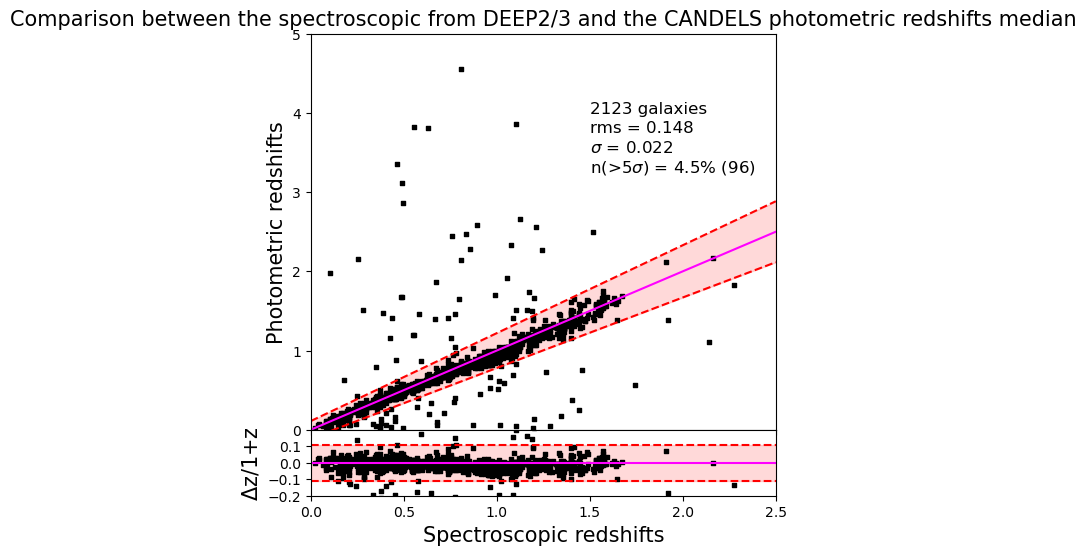

Number of galaxies = 2123
Variance = 0.022
Mean square (rms) = 0.148
n(>5sigma) = 96 Percentage = 4.5


In [10]:
fig,(ax1,ax2)= plt.subplots(2,1,figsize=(6,6),gridspec_kw={'height_ratios': 
                       [12,2]},sharex=True)

ax1.set_title('Comparison between the spectroscopic from DEEP2/3 and the CANDELS photometric redshifts median', fontsize=15)
ax1.set_ylabel('Photometric redshifts', fontsize = 15)
ax1.set_ylim(0,5)
ax1.plot(np.arange(10), color='magenta')
ax1.plot(x1,y11,'--', color= 'red')
ax1.plot(x1,y12,'--', color= 'red')
ax1.fill_between(x1,y11,y12,alpha=0.15, color='red')
ax1.scatter(D[:,2],D[:,1], color='k', marker= 's', s= 8.5)
ax1.text(1.5,4,'2123 galaxies',fontsize=12)
ax1.text(1.5,3.75,'rms = 0.148',fontsize=12)
ax1.text(1.5,3.50,r'$\sigma$ = 0.022',fontsize=12)
ax1.text(1.5,3.25,r'n(>5$\sigma$) = 4.5% (96)',fontsize=12)


ax2.axhline(y=0,xmax=2.5, color='magenta')
x2= np.arange(0,10,0.1)
y21= 5*sigma
y22= -5*sigma
ax2.axhline(y=5*sigma, xmax=2.5,color= 'red', linestyle='--')
ax2.axhline(y=-5*sigma, xmax=2.5,color= 'red', linestyle='--')
ax2.set_xlabel('Spectroscopic redshifts', fontsize= 15)
ax2.set_ylabel('$\Delta$z/1+z', fontsize = 15)
ax2.set_ylim(-0.2,0.2)
ax2.set_xlim(0,2.5)
ax2.set_yticks(np.arange(-0.2,0.2,0.1))
ax2.fill_between(x2,y21,y22,alpha=0.15, color='red')
ax2.scatter(D[:,2],dif, color='k', marker= 's', s= 8.5)

plt.subplots_adjust(hspace=0)
plt.show()
print('Number of galaxies =',d)              #Count how many galaxies appear in the graph 
print('Variance =',sigma)                    #measures the dispersion of the data
print('Mean square (rms) =', rms)            #mean square value
print('n(>5sigma) =',N,'Percentage =',p)     #total number of galaxies outside the 5sigma region

## Colour maps:

In [11]:
#By entering the columns we want from the 'multi-wavelenght' catalog that represent the flows measured in a particular photometric band
#in microjanskys, it converts them to AB magnitudes. It returns both data matrices. 
def flux_mag(regis):           
    flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
    m= -2.5*np.log10(flux*10**(-6))+8.90
    regis= np.array([6])
    class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
    regis= np.array([2])
    zphot= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,1,regis)
    regis= np.array([75])
    zspec= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
    M= np.concatenate((zspec,class_star,zphot,m), axis=1)  
    mA= M[M[:,1]<0.7]                            #Remove rows that have 'CLASS_STAR' > 0.7
    mAB= mA[mA[:,3]<26.5]                        #Remove rows that have 'F160W' > 26.5
    d_mAB= np.shape(mAB)[(0)]                    #to find out how many galaxies it is using
    print(d_mAB,'galaxies')
    mstar= -2.5*np.log10(flux*10**(-6))+8.90
    Mstar= np.concatenate((class_star, mstar), axis=1)     #Add the 'CLASS_STAR' column
    mA_star= Mstar[Mstar[:,0]>0.9]                         #Remove rows that have 'CLASS_STAR' <0.85
    mAB_star= mA_star[mA_star[:,1]<22]                     #Remove rows that have 'F160W' >22
    d_mAB_star= np.shape(mAB_star)[(0)]                    #to find out how many stars it is using
    print(d_mAB_star,'stars')
    return flux, mAB, mAB_star
#For galaxies, the returned matrices will have 8 columns (the first is 'zspec', the second 'Class-star', and the third 'zphot'),
#with the fourth column being for the 'F160W' band. The last four columns can be divided into two double columns. 
#These correspond to any four bands. The order of the subcolumns is important, depending on the bands. 
#The bluest band will be on the left, and the reddest on the right. 

In [12]:
regis= np.array([25,9,11,17,19])     #bands F160W, g', r', F606W, F814W
Flux,Mag,Mag_star= flux_mag(regis)
#print(Mag)

30059 galaxies
246 stars


C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:5: RuntimeWarning: invalid value encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:17: RuntimeWarning: invalid value encountered in log10
  mstar= -2.5*np.log10(flux*10**(-6))+8.90


In [13]:
#Calculate the color indices of the two double columns of the Mag and Mag_star matrices.
def color(Mag,Mag_star):
    c1= Mag[:,4]-Mag[:,5]
    c2= Mag[:,6]-Mag[:,7]
    C= np.column_stack((c1,c2))
    c1_star= Mag_star[:,2]-Mag_star[:,3]
    c2_star= Mag_star[:,4]-Mag_star[:,5]
    C_star= np.column_stack((c1_star,c2_star))
    #print(C, C_star)
    return C, C_star

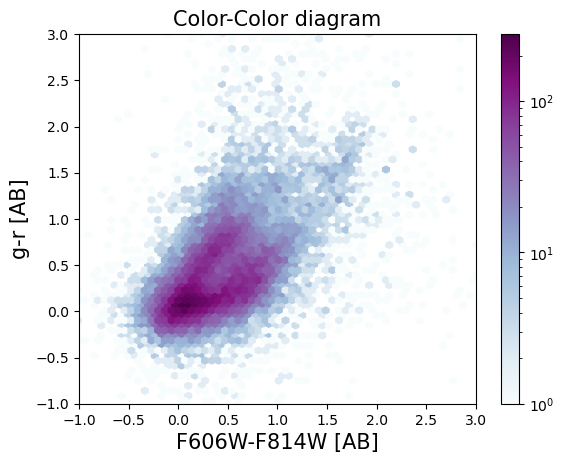

In [14]:
cA, cA_star= color(Mag,Mag_star)                      #color indices g'-r' (first column) and F606W-F814W (second column)
plt.figure()
plt.hexbin(cA[:,1],cA[:,0],gridsize=200,bins='log',cmap='BuPu')
plt.colorbar()
plt.xlim(-1,3)
plt.ylim(-1,3)
plt.title('Color-Color diagram',fontsize=15)
plt.xlabel('F606W-F814W [AB]',fontsize=15)
plt.ylabel('g-r [AB]',fontsize=15)
plt.show()

In [15]:
regis= np.array([25,9,11,17,19])                #bands F160W,g',r',F606W,F814W
Flux1,Mag1,Mag_star1= flux_mag(regis)
cA, cA_star= color(Mag1,Mag_star1)
regis= np.array([25,11,13,21,25])               #bands F160W,r',i',F125W,F160W
Flux2,Mag2,Mag_star2= flux_mag(regis)
cB, cB_star= color(Mag2,Mag_star2)
regis= np.array([25,11,13,29,31])               #bands F160W,r',i',H,Ks
Flux3,Mag3,Mag_star3= flux_mag(regis)
cC, cC_star= color(Mag3,Mag_star3)
regis= np.array([25,9,15,15,45])                #bands F160W,g',z',z',3.6um
Flux4,Mag4,Mag_star4= flux_mag(regis)
cD, cD_star= color(Mag4,Mag_star4)
regis= np.array([25,15,25,29,31])               #bands F160W,z',F160W,H,Ks
Flux5,Mag5,Mag_star5= flux_mag(regis)
cE, cE_star= color(Mag5,Mag_star5)
regis= np.array([25,9,21,39,43])                #bands F160W,g',F125W,H1,K
Flux6,Mag6,Mag_star6= flux_mag(regis)
cF, cF_star= color(Mag6,Mag_star6)

indcolor= np.column_stack((cA,cB,cC,cD,cE,cF))  
print(np.shape(indcolor)[(1)])                                                      #to find out the number of color columns
indcolor_star= np.column_stack((cA_star,cB_star,cC_star,cD_star,cE_star,cF_star,))  #star color indices
#print(len(indcolor.shape))

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:5: RuntimeWarning: invalid value encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:17: RuntimeWarning: invalid value encountered in log10
  mstar= -2.5*np.log10(flux*10**(-6))+8.90


30059 galaxies
246 stars
30059 galaxies
246 stars
30059 galaxies
246 stars


C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:5: RuntimeWarning: divide by zero encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90


30059 galaxies
246 stars


C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:17: RuntimeWarning: divide by zero encountered in log10
  mstar= -2.5*np.log10(flux*10**(-6))+8.90


30059 galaxies
246 stars
30059 galaxies
246 stars
12


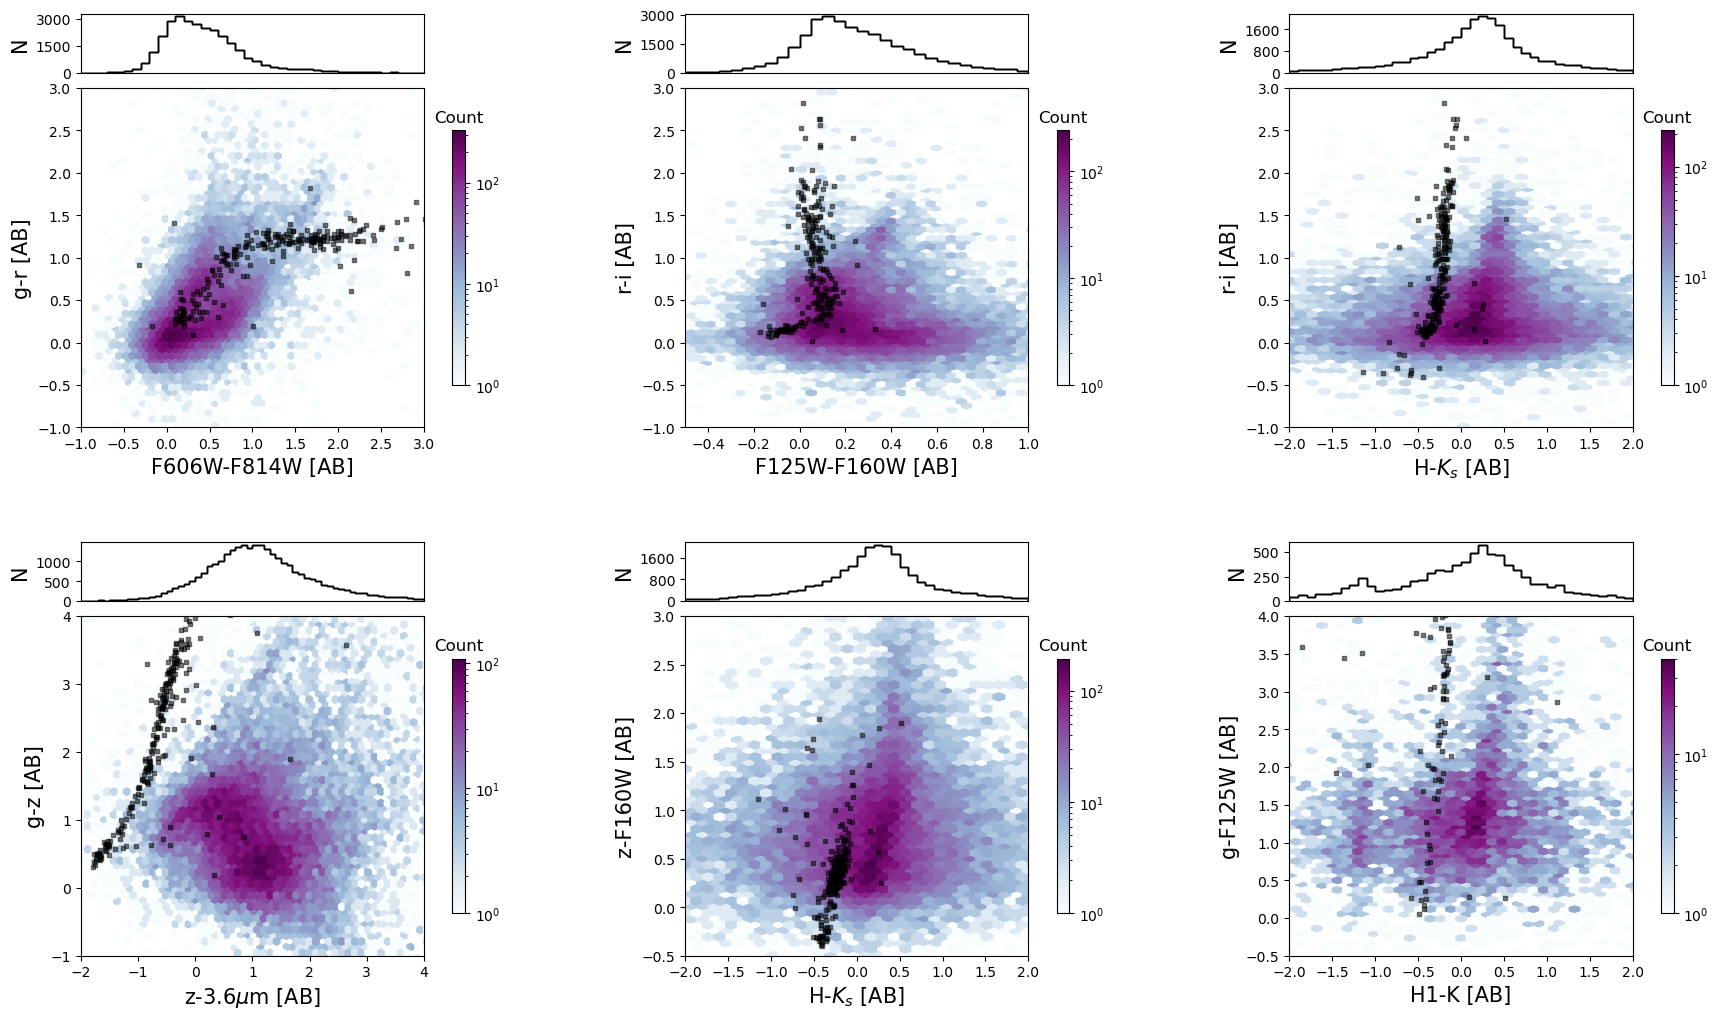

30059 galaxies
246 stars


In [16]:
fig,ax= plt.subplots(5,3,figsize=(17,10),gridspec_kw={'height_ratios': 
                       [1.75,10,1.75,1.75,10]},constrained_layout= True)
for i in range (0,3):
    #print(i)
    ax[2,i].plot()
    ax[2,i].axis('off')
    ax[1,0].set_xlabel('F606W-F814W [AB]', fontsize= 15)
    ax[1,1].set_xlabel('F125W-F160W [AB]', fontsize= 15)
    ax[1,2].set_xlabel('H-$K_s$ [AB]', fontsize= 15)
    ax[1,0].set_ylabel('g-r [AB]', fontsize = 15)
    ax[1,1].set_ylabel('r-i [AB]', fontsize = 15)
    ax[1,2].set_ylabel('r-i [AB]', fontsize = 15)
    ax[1,i].set_ylim(-1,3)
    ax[1,0].set_xlim(-1,3)
    ax[1,1].set_xlim(-0.5,1)
    ax[1,2].set_xlim(-2,2)
    graf= ax[1,i].hexbin(indcolor[:,2*i+1],indcolor[:,2*i],gridsize=175,bins='log',cmap='BuPu')
    cb= fig.colorbar(graf, ax=ax[1,i],shrink=0.75)
    cb.ax.set_title('Count')
    ax[1,i].scatter(indcolor_star[:,2*i+1],indcolor_star[:,2*i],color='black',marker='s',s=8.5,alpha=0.5)
for i in range (0,3):
    #print(i)
    ax[4,0].set_xlabel('z-3.6$\mu$m [AB]', fontsize= 15)
    ax[4,1].set_xlabel('H-$K_s$ [AB]', fontsize= 15)
    ax[4,2].set_xlabel('H1-K [AB]', fontsize= 15)
    ax[4,0].set_ylabel('g-z [AB]', fontsize = 15)
    ax[4,1].set_ylabel('z-F160W [AB]', fontsize = 15)
    ax[4,2].set_ylabel('g-F125W [AB]', fontsize = 15)
    ax[4,0].set_ylim(-1,4)
    ax[4,1].set_ylim(-0.5,3)
    ax[4,2].set_ylim(-0.5,4)
    ax[4,0].set_xlim(-2,4)
    ax[4,1].set_xlim(-2,2)
    ax[4,2].set_xlim(-2,2)
    graf= ax[4,i].hexbin(indcolor[:,2*i+7],indcolor[:,2*i+6],gridsize=175,bins='log',cmap='BuPu')
    cb= fig.colorbar(graf, ax=ax[4,i],shrink=0.75)
    cb.ax.set_title('Count')
    ax[4,i].scatter(indcolor_star[:,2*i+7],indcolor_star[:,2*i+6],color='black',marker='s',s=8.5,alpha=0.5)
    
for j in range (0,3):
    ax[0,j].set_ylabel('N', fontsize = 15)
    ax[0,j].yaxis.set_major_locator(MaxNLocator(3))
    ax[0,0].set_xlim(-1,3)
    ax[0,1].set_xlim(-0.5,1)
    ax[0,2].set_xlim(-2,2)
    ax[0,j].set_xticks([])
    ax[0,0].hist(indcolor[:,1],bins=40,range=(-1,3),histtype='step',color='black')     #ind.color bin of 0.1
    ax[0,1].hist(indcolor[:,3],bins=30,range=(-0.5,1),histtype='step',color='black')   #ind.color bin of 0.05
    ax[0,2].hist(indcolor[:,5],bins=40,range=(-2,2),histtype='step',color='black')     #ind.color bin of 0.1
for j in range (0,3):
    ax[3,j].set_ylabel('N', fontsize = 15)
    ax[3,j].yaxis.set_major_locator(MaxNLocator(3))
    ax[3,0].set_xlim(-2,4)
    ax[3,1].set_xlim(-2,2)
    ax[3,2].set_xlim(-2,2)
    ax[3,j].set_xticks([])
    ax[3,0].hist(indcolor[:,7],bins=60,range=(-2,4),histtype='step',color='black')   #ind.color bin of 0.01
    ax[3,1].hist(indcolor[:,9],bins=40,range=(-2,2),histtype='step',color='black')   #ind.color bin of 0.01
    ax[3,2].hist(indcolor[:,11],bins=40,range=(-2,2),histtype='step',color='black')  #ind.color bin of 0.01


fig.set_constrained_layout_pads(w_pad=0.002,h_pad=0.001,wspace=0.2,hspace=0.005)
plt.savefig("color_color.jpg",dpi=300,bbox_inches='tight')
plt.show()
print(np.shape(indcolor)[(0)], 'galaxies')          
print(np.shape(indcolor_star)[(0)], 'stars') 

In [17]:
#Function that calculates quartiles
def perc(data):
    perc25= np.nanpercentile(data,25)  #quartil Q1
    med= np.nanpercentile(data,50)     #quartil Q2 (mediana)
    perc75= np.nanpercentile(data,75)  #quartil Q3
    R_int= perc75-perc25               #interquartile range
    p= [perc25,med,perc75]
    print('Quartiles (Q1,Q2,Q3):',np.round(p,3))
    print('Interquartile range of the sample:',round(R_int,3))
    return p

## Cosmological distances

I calculate the distance in Mpc of galaxies (commobile, by luminosity, by angular diameter and radial physics), their distance modulus and their absolute magnitude.

In addition, there is another defined function that eliminates catastrophic errors in the photometric redshift for z [0, 2.5] that have spectroscopic measurements.

The last two defined functions correspond to the trapezoidal method for solving the comovelo distance integral numerically.

In [18]:
#I define a function that calculates the galaxy's distance in Mpc, the distance modulus, and its absolute magnitude in a band,
#simply by inputting a series of photometric redshifts and the filters I want to use.
def dist_Mag(zphot,regis):
    def f(z):
        H= 67.3     #[km/s/Mpc]
        c= 300000   #[km/s]
        Om_M= 0.315
        Om_A= 0.685
        return (c/H)*((Om_M*((1+z)**3)+Om_A)**(-1/2)) #flat universe with dark matter and dark energy (Lambda-CDM)
    def regla_trapecios(f,a,b,n):    #Solve definite integrals that have no analytical solution using a numerical method
        t=[]
        for i in range (0,len(b)):
            h=(b[i]-a)/n
            zs=np.linspace(a,b[i],n+1)
            ys=f(zs)
            r=h*(ys[0]+2*sum(ys[1:n])+ys[n])/2
            t.append(r)
        return t
    Dco=regla_trapecios(f,0,zphot,1000)                    #Comomobile distance [Mpc]
    DL= Dco*(1+zphot)                                      #Distance by luminosity [Mpc]
    DF= Dco/(1+zphot)                                      #Radial physical distance = Distance per angular diameter (if k=0) [Mpc]
    mu= 5*(np.log10(DL)+5)                                 #Distance module
    flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
    Map= -2.5*np.log10(flux*10**(-6))+8.90
    a= np.zeros((Map.shape[0],1))
    for i in range (0,len(regis)):
        u= Map[:,i]-mu[:,0]
        a= np.insert(a,a.shape[1],u,1)
        Mabs= np.delete(a, 0, 1)
    print(Mabs,'absolute magnitudes in the bands r,F160W,8.0um')
    print('Number of galaxies:',np.shape(Mabs)[(0)])
    regis= np.array([6])
    class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)
    regis= np.array([75])
    zspec= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
    X= np.concatenate((zphot,DF,mu,Map,Mabs), axis=1)
    dX= np.concatenate((zspec,class_star,X), axis=1)
    dX= dX[dX[:,1] < 0.7]               #Remove rows that have 'class_star' > 0.7
    dX= dX[dX[:,5]<26.5]                #Remove rows with an apparent magnitude in the 'F160W' filter >26.5
    d= np.shape(dX)[(0)]                #to find out how many galaxies it is using
    print('Matrix of distances and absolute magnitudes:',dX,dX.shape,'Number of galaxies:',d)
    return dX
###############################################################################################################
def filt_err(data,sigma):                       
    def dif_z(zphot,zspec): #calculate (zphot-zspec)/(1+zspec)
        return (zphot-zspec)/(1+zspec)         #This function eliminates catastrophic errors in the values ​​obtained
    a= []                                      #photometric redshift values ​​with respect to their spectroscopic measurements around the 
    for i in range (np.shape(data)[(0)]):      #interval z (0,2.5). 
        if data[i,0]>0:
            dif= dif_z(data[i,2],data[i,0])    #The second column data[:,1] corresponds to 'class_star' (already filtered)
            if dif<-5*sigma or dif>5*sigma:    #Sigma is the dispersion of the calculated values ​​of 'zphot'
                #print('Out the limit')
                u= i
                a.append(u)
                A= np.delete(data,a,axis=0)
            else: 
                #print('Within the limit')
                pass
        else:
            #print('It hasn't got spectroscopic redshift')
            pass
    print('Filtered matrix of catastrophic errors:',A,A.shape,'Number of galaxies:',np.shape(A)[(0)])
    return A
##################################################################################################################
def f(z):
        H= 67.3     #[km/s/Mpc]
        c= 300000   #[km/s]
        Om_M= 0.315
        Om_A= 0.685
        return (c/H)*((Om_M*((1+z)**3)+Om_A)**(-1/2)) #flat universe with dark matter and dark energy (Lambda-CDM)
def num_trapecios(f,a,b,n):     #Here the input value b has to be a single number
    h=(b-a)/n
    zs=np.linspace(a,b,n+1)
    ys=f(zs)
    r=h*(ys[0]+2*sum(ys[1:n])+ys[n])/2
    return r
def grafica_trapecios(f,a,b,n):  
    x=np.linspace(a,b)
    y=f(x)
    fig,ax=plt.subplots()
    ax.plot(x,y,'b',linewidth=1.7)
    ax.set_ylim(bottom=0)
    ix=np.linspace(a,b,n+1)
    iy=f(ix)
    for i in range(n):
        verts=[(ix[i],0),(ix[i],iy[i]),(ix[i+1],iy[i+1]),(ix[i+1],0)]
        poly=Polygon(verts,facecolor='0.9',edgecolor='0.5')
        ax.add_patch(poly)
    return plt
#####################################################################################################################
def diam(zphot,esc):
    regis= np.array([6])
    class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)
    regis= np.array([75])
    zspec= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
    regis= np.array([25])
    flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
    Map= -2.5*np.log10(flux*10**(-6))+8.90
    regis= np.array([63])
    l= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,6,regis)
    r= esc*2*l                  #Diameters 50% in [arcsec]
    cosmo=FlatLambdaCDM(H0=67.3, Om0=0.315)
    kpc_arcmin= cosmo.kpc_proper_per_arcmin(zphot)
    kpc_arcseg= kpc_arcmin.value/60 
    R= r*kpc_arcseg        #Size (using 50% diameter) in kpc by astropy
    regis= np.array([16,17])
    A_B= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,6,regis)
    e= 1-(A_B[:,1]/A_B[:,0])            #ellipticity
    L= np.concatenate((zspec,class_star,zphot,Map,r), axis=1)
    LL= np.column_stack((L,e,R))
    dL= LL[LL[:,1] < 0.7]               #Remove rows that have 'class_star' > 0.7
    DL= dL[dL[:,3]<26.5]                #Remove rows with an apparent magnitude in the 'F160W' filter >26.5
    d= np.shape(DL)[(0)]                #to find out how many galaxies it is using
    print('Matrix of galaxy sizes:',DL,'Number of galaxies:',d)
    return DL

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:5: RuntimeWarning: divide by zero encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:5: RuntimeWarning: invalid value encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:17: RuntimeWarning: divide by zero encountered in log10
  mstar= -2.5*np.log10(flux*10**(-6))+8.90
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3807431910.py:17: RuntimeWarning: invalid value encountered in log10
  mstar= -2.5*np.log10(flux*10**(-6))+8.90


30059 galaxies
246 stars
Filtered matrix of catastrophic errors: [[-1.00000000e+00  3.50000000e-01  1.70000000e+00 ...  2.61464916e+01
   2.65989090e+01  2.79231037e+01]
 [-1.00000000e+00  2.00000000e-02  3.96100000e+00 ...  2.59626710e+01
   2.64973970e+01  2.59368531e+01]
 [-1.00000000e+00  6.00000000e-02  1.06900000e+00 ...  2.63956657e+01
   2.64927750e+01  2.59157974e+01]
 ...
 [-1.00000000e+00  1.00000000e-01  1.93900000e+00 ...  2.71361960e+01
   2.65745384e+01  2.70835895e+01]
 [-1.00000000e+00  1.20000000e-01  4.86400000e+00 ...  2.58642153e+01
   2.80306995e+01  2.57751706e+01]
 [-1.00000000e+00  3.00000000e-02  1.58600000e+00 ...  2.68952907e+01
   2.66221060e+01  2.69606099e+01]] (29965, 8) Number of galaxies: 29965
30059 galaxies
246 stars
Filtered matrix of catastrophic errors: [[-1.00000000e+00  3.50000000e-01  1.70000000e+00 ...  2.61464916e+01
   2.79231037e+01  2.33086568e+01]
 [-1.00000000e+00  2.00000000e-02  3.96100000e+00 ...  2.59626710e+01
   2.59368531e+01  2.5

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\844256072.py:22: RuntimeWarning: divide by zero encountered in log10
  mu= 5*(np.log10(DL)+5)                                 #Distance module
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\844256072.py:24: RuntimeWarning: divide by zero encountered in log10
  Map= -2.5*np.log10(flux*10**(-6))+8.90
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\844256072.py:24: RuntimeWarning: invalid value encountered in log10
  Map= -2.5*np.log10(flux*10**(-6))+8.90


[[-22.27666037 -16.89407376 -22.27666037 -22.82357164]
 [-22.3106279  -18.14656224 -22.3106279  -24.62852523]
 [-18.87455789 -16.4516497  -18.87455789 -19.90618527]
 ...
 [-17.1668138  -14.19207581 -17.1668138           nan]
 [-19.09704061 -18.75468079 -19.09704061 -21.62353526]
 [-19.31003261 -17.64657106 -19.31003261 -20.85555225]] absolute magnitudes in the bands r,F160W,8.0um
Number of galaxies: 41457
Matrix of distances and absolute magnitudes: [[-1.00000000e+00  3.50000000e-01  1.70000000e+00 ... -1.68940738e+01
  -2.22766604e+01 -2.28235716e+01]
 [-1.00000000e+00  2.00000000e-02  3.96100000e+00 ... -1.81465622e+01
  -2.23106279e+01 -2.46285252e+01]
 [-1.00000000e+00  6.00000000e-02  1.06900000e+00 ... -1.64516497e+01
  -1.88745579e+01 -1.99061853e+01]
 ...
 [-1.00000000e+00  1.00000000e-01  1.93900000e+00 ... -1.89013947e+01
  -1.98960502e+01 -2.13084256e+01]
 [-1.00000000e+00  1.20000000e-01  4.86400000e+00 ...             nan
  -2.26550412e+01             nan]
 [-1.00000000e+0

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\844256072.py:98: RuntimeWarning: invalid value encountered in log10
  Map= -2.5*np.log10(flux*10**(-6))+8.90


Matrix of galaxy sizes: [[-1.          0.35        1.7        ...  0.95796     0.49100632
   8.33599754]
 [-1.          0.02        3.961      ...  0.62556     0.32355212
   4.47235584]
 [-1.          0.06        1.069      ...  0.46404     0.07674815
   3.88681623]
 ...
 [-1.          0.1         1.939      ...  0.46896     0.06728232
   4.04514269]
 [-1.          0.12        4.864      ...  0.3804      0.01537386
   2.47935956]
 [-1.          0.03        1.586      ...  0.51924     0.25452609
   4.52359206]] Number of galaxies: 30059
Filtered matrix of catastrophic errors: [[-1.          0.35        1.7        ...  0.49100632  8.33599754
   8.34176112]
 [-1.          0.02        3.961      ...  0.32355212  4.47235584
   4.4754493 ]
 [-1.          0.06        1.069      ...  0.07674815  3.88681623
   3.88950344]
 ...
 [-1.          0.1         1.939      ...  0.06728232  4.04514269
   4.04793962]
 [-1.          0.12        4.864      ...  0.01537386  2.47935956
   2.48107488]
 [-1.   

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\4232763398.py:32: RuntimeWarning: invalid value encountered in log10
  Map= -2.5*np.log10(flux*10**(-6))+8.90


Filtered matrix of catastrophic errors: [[-1.00000000e+00  3.50000000e-01  1.70000000e+00  2.33086568e+01
  -2.03400000e+01 -2.22300000e+01]
 [-1.00000000e+00  2.00000000e-02  3.96100000e+00  2.54900304e+01
  -2.17900000e+01 -2.25000000e+01]
 [-1.00000000e+00  6.00000000e-02  1.06900000e+00  2.54718684e+01
  -1.76400000e+01 -1.79400000e+01]
 ...
 [-1.00000000e+00  1.00000000e-01  1.93900000e+00  2.60385645e+01
  -1.84900000e+01 -1.76500000e+01]
 [-1.00000000e+00  1.20000000e-01  4.86400000e+00  2.56710229e+01
  -1.97100000e+01 -1.79900000e+01]
 [-1.00000000e+00  3.00000000e-02  1.58600000e+00  2.63034496e+01
  -1.78500000e+01 -1.69600000e+01]] (29965, 6) Number of galaxies: 29965
Filtered matrix of distances and absolute magnitudes with zspec>0: [[ 7.38320000e-01  4.20000000e-01  6.90000000e-01 ... -1.74495224e+01
  -2.05923211e+01 -1.91466456e+01]
 [ 7.38320000e-01  1.00000000e-02  6.23000000e-01 ... -1.85982121e+01
  -2.09640961e+01             nan]
 [ 1.11931000e+00  1.00000000e-02 

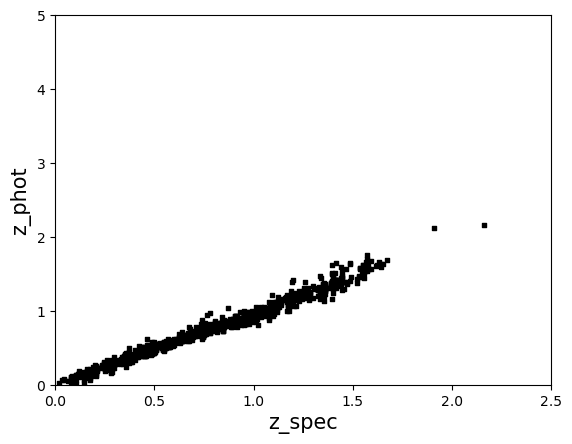

Comobile= 5323.651933668439 Mpc By luminosity= 15970.955801005315 Mpc Per angular diameter= 1774.5506445561462 Mpc


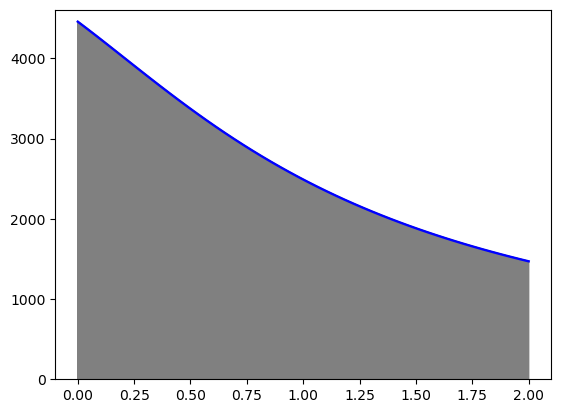

Comobile= 5319.968520824864 Mpc By luminosity= 15959.905562474592 Mpc Per angular diameter= 1773.3228402749546 Mpc
Difference in Comobile Distance= 0.069 Difference in Luminosity Distance= 0.069 Difference in Angular Diameter Distance= 0.069
---------------------------------------------------------------------------------------------------------------------------
Quartiles (Q1,Q2,Q3): [0.71 1.26 1.89]
Interquartile range of the sample: 1.181
Quartiles (Q1,Q2,Q3): [0.401 0.715 1.033]
Interquartile range of the sample: 0.632
Quartiles (Q1,Q2,Q3): [0.81  1.46  2.114]
Interquartile range of the sample: 1.304
--------------------------------------------------------------------------------------------
Quartiles (Q1,Q2,Q3): [43.606 45.18  46.163]
Interquartile range of the sample: 2.557
Quartiles (Q1,Q2,Q3): [-20.35 -19.09 -17.74]
Interquartile range of the sample: 2.61
Quartiles (Q1,Q2,Q3): [-20.53 -19.13 -17.77]
Interquartile range of the sample: 2.76
---------------------------------------

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\4232763398.py:86: RuntimeWarning: invalid value encountered in divide
  difr2= (abs(B[:,6]-B[:,7])/((B[:,6]+B[:,7])/2))*100  #porcentaje de diferencia entre los diámetros 50 de astropy y propios


In [19]:
regis= np.array([25,7,15,17,19])        #bands F160W,u',z',F606W,F814W
Flux1,Mag1,Mag1_star= flux_mag(regis)
Mag1fltr= filt_err(Mag1,0.022)
cA, cA_star= color(Mag1fltr,Mag1_star)
regis= np.array([25,7,15,19,25])        #bands F160W,u',z',F814W,F160W
Flux2,Mag2,Mag2_star= flux_mag(regis)
Mag2fltr= filt_err(Mag2,0.022)
cB, cB_star= color(Mag2fltr,Mag2_star)
indcolor= np.column_stack((cA,cB))
print('Color index matrix:',indcolor,'Number of galaxies=',np.shape(indcolor)[(0)])
regis= np.array([2])
zphot= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,1,regis)
regis= np.array([25,7,25,51])  #bands F160W,u',F160W,8.0um
dataX= dist_Mag(zphot,regis)
A= filt_err(dataX,0.022)     #Sigma=0.022 corresponds to the values ​​of 'photometric redshift median v1' 
#[0]zspec [1]class_star [2]zphot [3]dist_fis [4]modulo_dist [5]-[8]mag_aparente [9]-[12]mag_absoluta *[5]and[9] are from F160W
A_spec= A[A[:,0]>0] #Capture those with an observed zspec value, disregarding catastrophic errors.

esc= 0.06      #WFC3-IR detector plate scale in the F160W band [arcsec/px]
dataY= diam(zphot,esc)
t= (dataY[:,4]/206265)*dataX[:,3]*1000 #galaxy size [kpc] using D_50
dataZ= np.column_stack((dataY,t))
B= filt_err(dataZ,0.022)
#[0]zspec [1]class_star [2]zphot [3]F160W apparent_mag [4]D_50 (arcsec) [5]ellipticity [6]astropy D_50 (kpc) [7]D_50 (kpc)

regis= np.array([6])
class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)
regis= np.array([75])
zspec= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
regis= np.array([25])
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
Map= -2.5*np.log10(flux*10**(-6))+8.90
regis= np.array([20,24])
M_abs= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis) #Mag.abs. rest-frame V y K
dataC= np.column_stack((zspec,class_star,zphot,Map,M_abs))
dataC= dataC[dataC[:,1]<0.7]
dataC= dataC[dataC[:,3]<26.5]
C= filt_err(dataC,0.022)
#[0]zspec [1]class_star [2]zphot [3]mag_apparent of F160W [4]absolute rest-frame magnitudes in the V and K bands([5])
#############################################################################################################################
#Verify that catastrophic photometric redshift errors for z[0,2.5] that have spectroscopic measurements have been removed.
W= A[A[:,0]>0]                #remove rows that have 'zspec' <0
r= np.shape(W)[(0)]           #to find out how many galaxies it is using
print('Filtered matrix of distances and absolute magnitudes with zspec>0:',W,'Number of galaxias:',r)
plt.figure()
plt.scatter(W[:,0], W[:,2], color= 'black', marker='s',s=8.5) 
plt.xlim(0,2.5)
plt.ylim(0,5)
plt.xlabel('z_spec',fontsize=15)
plt.ylabel('z_phot',fontsize=15)
plt.show()
############################################################################################################################
#Verify that the cosmological distances have been calculated correctly using the trapezoidal rule by comparing them with the results returned by astropy.
a=0
b=2    #redshifts of interest
n=1000
area=num_trapecios(f,a,b,n) #comobile distance
ld= area*(1+b)              #Distance by luminosity
add= area/(1+b)             #Distance per angular diameter
print('Comobile=',area,'Mpc','By luminosity=',ld,'Mpc','Per angular diameter=',add,'Mpc')
g=grafica_trapecios(f,a,b,n)
g.show()
cosmo=FlatLambdaCDM(H0=67.3, Om0=0.315)
ccd= cosmo.comoving_distance(b)
cld= cosmo.luminosity_distance(b)
cadd= cosmo.angular_diameter_distance(b)
print('Comobile=',ccd,'By luminosity=',cld,'Per angular diameter=',cadd)
dif_cd= round((abs(area-ccd.value)/((area+ccd.value)/2))*100,3)   #percentage difference between the two calculated comoving distances
dif_ld= round((abs(ld-cld.value)/((ld+cld.value)/2))*100,3)       #percentage difference between the two distances calculated by luminosity
dif_add= round((abs(add-cadd.value)/((add+cadd.value)/2))*100,3)  #percentage difference between the two calculated angular diameter distances
print('Difference in Comobile Distance=',dif_cd,'Difference in Luminosity Distance=',dif_ld,'Difference in Angular Diameter Distance=',dif_add)
print('---------------------------------------------------------------------------------------------------------------------------')
###########################################################################################################################
cuart_uz= perc(indcolor[:,0])
cuart_814160= perc(indcolor[:,3])
cuart_z= perc(A[:,2])
print('--------------------------------------------------------------------------------------------')
cuart_mu= perc(A[:,4])
cuart_V= perc(C[:,4])
cuart_K= perc(C[:,5])
print('--------------------------------------------------------------------------------------------')
cuart_e= perc(B[:,5])
cuart_T= perc(B[:,4])
cuart_t= perc(B[:,7])
print('--------------------------------------------------------------------------------------------')
difr2= (abs(B[:,6]-B[:,7])/((B[:,6]+B[:,7])/2))*100  #porcentaje de diferencia entre los diámetros 50 de astropy y propios
difTam_med2= round(np.nansum(difr2)/len(difr2),3)
print('Average difference between the size calculated by astropy and using the formula (both with D_50) =',difTam_med2)
print('--------------------------------------------------------------------------------------------')
print('Color index matrix: Number of galaxies=',np.shape(indcolor)[(0)])
print('Matrix A: Number of galaxies=',np.shape(A)[(0)])
print('Matrix dataX: Number of galaxies=', np.shape(dataX)[(0)])
print('Matrix B: Number of galaxies=',np.shape(B)[(0)])
print('Matrix C: Number of galaxies=',np.shape(C)[(0)])

## Histograms of the full sample

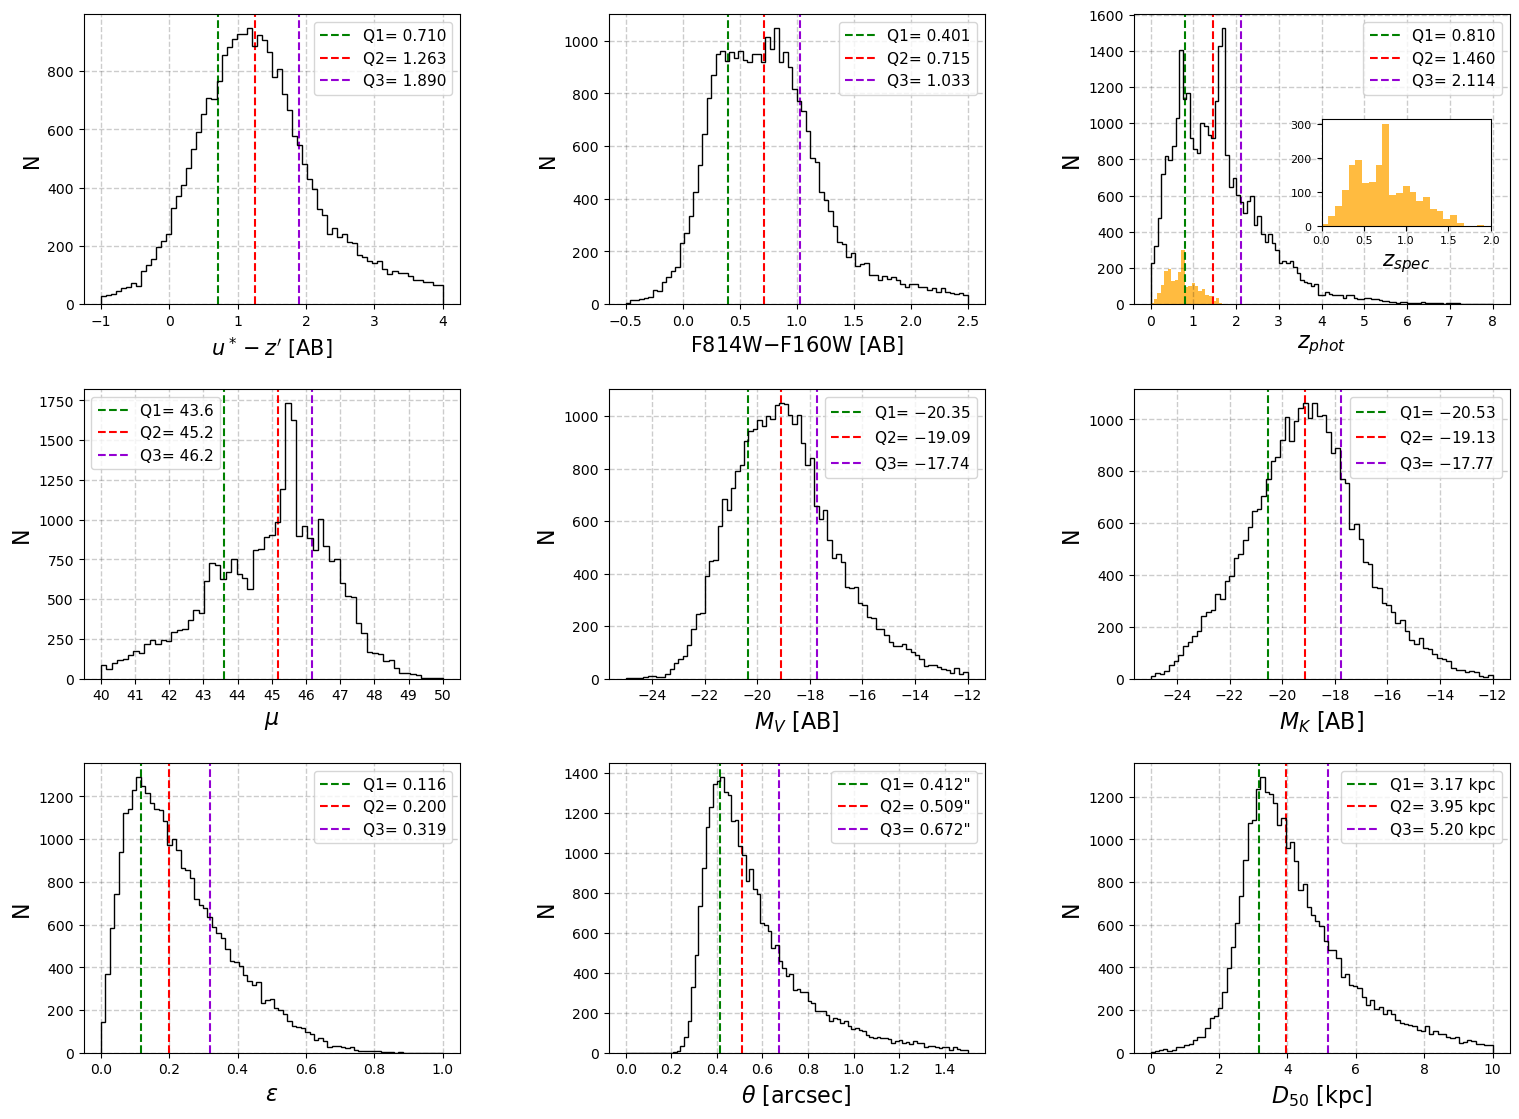

In [20]:
fig,ax= plt.subplots(3,3,figsize=(15,11),gridspec_kw={'width_ratios': 
                     [5,5,5],'height_ratios':[3,3,3]},constrained_layout= True)
x= np.histogram_bin_edges(indcolor[:,0],bins='fd',range=(-1,4))
ax[0,0].axvline(cuart_uz[0],linewidth=1.5,linestyle='dashed',color='green')
ax[0,0].axvline(cuart_uz[1],linewidth=1.5,linestyle='dashed',color='red')
ax[0,0].axvline(cuart_uz[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[0,0].hist(indcolor[:,0],bins=x,range=(-1,4),histtype='step',color='k')      #ind.color u-z
ax[0,0].legend(['Q1= 0.710','Q2= 1.263','Q3= 1.890'],loc='upper right',prop={'size':11})
ax[0,0].set_xlabel('$u^*-z\'$ [AB]', fontsize= 15)
ax[0,0].set_xticks(range(-1,5,1))
ax[0,0].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[0,0].set_ylabel('N', fontsize = 15)

x= np.histogram_bin_edges(indcolor[:,3],bins='fd',range=(-0.5,2.5))
ax[0,1].axvline(cuart_814160[0],linewidth=1.5,linestyle='dashed',color='green')
ax[0,1].axvline(cuart_814160[1],linewidth=1.5,linestyle='dashed',color='red')
ax[0,1].axvline(cuart_814160[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[0,1].hist(indcolor[:,3],bins=x,range=(-0.5,2.5),histtype='step',color='k')      #ind.color F814W-F160W
ax[0,1].legend(['Q1= 0.401','Q2= 0.715','Q3= 1.033'],loc='upper right',prop={'size':11})
ax[0,1].set_xlabel('F814W$-$F160W [AB]', fontsize= 15)
ax[0,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[0,1].set_ylabel('N', fontsize = 15)

x= np.histogram_bin_edges(A[:,2],bins='fd',range=(0,8))
ax[0,2].axvline(cuart_z[0],linewidth=1.5,linestyle='dashed',color='green')
ax[0,2].axvline(cuart_z[1],linewidth=1.5,linestyle='dashed',color='red')
ax[0,2].axvline(cuart_z[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[0,2].hist(A[:,2],bins=x,range=(0,8),histtype='step',color='k')                            #z_phot 
ax[0,2].legend(['Q1= 0.810','Q2= 1.460','Q3= 2.114'],loc='upper right',prop={'size':11})
x= np.histogram_bin_edges(A_spec[:,0],bins='fd',range=(0,2))
ax[0,2].hist(A_spec[:,0],bins=x,range=(0,2),histtype='barstacked',alpha=0.75,color='orange')
axins= ax[0,2].inset_axes([.5,.27,.45,.37],xlim=(0,2))
axins.hist(A_spec[:,0],bins=x,range=(0,2),histtype='barstacked',alpha=0.75,color='orange')   #z_spec 
axins.tick_params(axis='both',labelsize=8)
axins.set_xlabel('$z_{spec}$',fontsize = 15.5)
axins.set_yticks(range(0,400,100))

ax[0,2].set_xlabel('$z_{phot}$', fontsize= 16)
ax[0,2].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[0,2].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(A[:,4],bins='fd',range=(40,50)) 
ax[1,0].axvline(cuart_mu[0],linewidth=1.5,linestyle='dashed',color='green')
ax[1,0].axvline(cuart_mu[1],linewidth=1.5,linestyle='dashed',color='red')
ax[1,0].axvline(cuart_mu[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[1,0].hist(A[:,4],bins=x,range=(40,50),histtype='step',color='k')                        #distance module
ax[1,0].legend(['Q1= 43.6','Q2= 45.2','Q3= 46.2'],loc='upper left',prop={'size':11})
ax[1,0].set_xlabel('$\mu$', fontsize= 16)
ax[1,0].set_xticks(range(40,51,1))
ax[1,0].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[1,0].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(C[:,4],bins='fd',range=(-25,-12))
ax[1,1].axvline(cuart_V[0],linewidth=1.5,linestyle='dashed',color='green')
ax[1,1].axvline(cuart_V[1],linewidth=1.5,linestyle='dashed',color='red')
ax[1,1].axvline(cuart_V[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[1,1].hist(C[:,4],bins=x,range=(-25,-12),histtype='step',color='k')                  #absolute magnitude rest-frame V 
ax[1,1].legend(['Q1= $-20.35$','Q2= $-19.09$','Q3= $-17.74$'],loc='upper right',prop={'size':11})
ax[1,1].set_xlabel('$M_V$ [AB]', fontsize= 16)
ax[1,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[1,1].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(C[:,5],bins='fd',range=(-25,-12)) 
ax[1,2].axvline(cuart_K[0],linewidth=1.5,linestyle='dashed',color='green')
ax[1,2].axvline(cuart_K[1],linewidth=1.5,linestyle='dashed',color='red')
ax[1,2].axvline(cuart_K[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[1,2].hist(C[:,5],bins=x,range=(-25,-12),histtype='step',color='k')                  #absolute magnitude rest-frame K
ax[1,2].legend(['Q1= $-20.53$','Q2= $-19.13$','Q3= $-17.77$'],loc='upper right',prop={'size':11})
ax[1,2].set_xlabel('$M_K$ [AB]', fontsize= 16)
ax[1,2].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[1,2].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(B[:,5],bins='fd',range=(0,1))
ax[2,0].axvline(cuart_e[0],linewidth=1.5,linestyle='dashed',color='green')
ax[2,0].axvline(cuart_e[1],linewidth=1.5,linestyle='dashed',color='red')
ax[2,0].axvline(cuart_e[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[2,0].hist(B[:,5],bins=x,range=(0,1),histtype='step',color='k')                          #ellipticity
ax[2,0].legend(['Q1= 0.116','Q2= 0.200','Q3= 0.319'],loc='upper right',prop={'size':11})
ax[2,0].set_xlabel('$\epsilon$', fontsize= 16)
ax[2,0].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[2,0].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(B[:,4],bins='fd',range=(0,1.5))
ax[2,1].axvline(cuart_T[0],linewidth=1.5,linestyle='dashed',color='green')
ax[2,1].axvline(cuart_T[1],linewidth=1.5,linestyle='dashed',color='red')
ax[2,1].axvline(cuart_T[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[2,1].hist(B[:,4],bins=x,range=(0,1.5),histtype='step',color='k')                      #size in [arcsec]
ax[2,1].legend(['Q1= 0.412"','Q2= 0.509"', 'Q3= 0.672"'],loc='upper right',prop={'size':11})
ax[2,1].set_xlabel('$\\theta$ [arcsec]', fontsize= 16)
ax[2,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[2,1].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(B[:,7],bins='fd',range=(0,10))
ax[2,2].axvline(cuart_t[0],linewidth=1.5,linestyle='dashed',color='green')
ax[2,2].axvline(cuart_t[1],linewidth=1.5,linestyle='dashed',color='red')
ax[2,2].axvline(cuart_t[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[2,2].hist(B[:,7],bins=x,range=(0,10),histtype='step',color='k')                         #size in [kpc] 
ax[2,2].legend(['Q1= 3.17 kpc','Q2= 3.95 kpc','Q3= 5.20 kpc'],loc='upper right',prop={'size':11})
ax[2,2].set_xlabel('$D_{50}$ [kpc]', fontsize= 16)
ax[2,2].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[2,2].set_ylabel('N', fontsize = 16)

fig.set_constrained_layout_pads(w_pad=0.002,h_pad=0.001,wspace=0.15,hspace=0.08)
plt.savefig("hist_all_catalog.jpg",dpi=300,bbox_inches='tight')
plt.show()

## Spectroscopic vs Photometric redshifts

In [21]:
############################################################################################################################
################################################## VERSIoN 1 #################################################################
regis= np.array([75])
zspec_d23= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis) #zspec of DEEP2/3
regis= np.array([10])
zspec_d3= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,1,regis) #zspec of DEEP3
regis= np.array([2])
zphot_v1= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,1,regis)  #zphot from version 1
regis= np.array([6])
class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
regis= np.array([25])     #band F160W
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m160= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W band
m= np.concatenate((class_star,zphot_v1,zspec_d23,zspec_d3,m160),axis=1)
M= m[m[:,3]<0]       #Remove rows that have 'DEEP3 zspec' > 0
zspec_d2= M[:,2]     #zspec of DEEP2
D23= np.concatenate((class_star,zphot_v1,zspec_d23,m160),axis=1) #DEEP2/3
D2= M                                                            #DEEP2
D3= np.concatenate((class_star,zphot_v1,zspec_d3,m160),axis=1)   #DEEP3
data23= D23[D23[:,0]<0.7]         #Remove rows that have 'class_star' > 0.7
data23= data23[data23[:,3]< 26.5] #Remove rows that have 'm_F160W' > 26.5
deep23= data23[data23[:,2]>0]     #remove rows that have 'zspec_d2' <0
d23= np.shape(deep23)[(0)]        #to find out how many galaxies it is using
print(deep23,'Number of galaxies DEEP2/3 (v1):',d23)
data2= D2[D2[:,0]<0.7]         #Remove rows that have 'class_star' > 0.7
data2= data2[data2[:,4]< 26.5] #Remove rows that have 'm_F160W' > 26.5
deep2= data2[data2[:,2]>0]     #remove rows that have 'zspec_d2' <0
d2= np.shape(deep2)[(0)]       #to find out how many galaxies it is using
print(deep2,'Number of galaxies DEEP2 (v1):',d2)
data3= D3[D3[:,0]<0.7]         #Remove rows that have 'class_star' > 0.7
data3= data3[data3[:,3]< 26.5] #Remove rows that have 'm_F160W' > 26.5
deep3= data3[data3[:,2]>0]     #remove rows that have 'zspec_d3' <0
d3= np.shape(deep3)[(0)]       #to find out how many galaxies it is using
print(deep3,'Number of galaxies DEEP3 (v1):',d3)
zphotot_v1= np.concatenate((class_star,zphot_v1,m160),axis=1)
zphotot_v1= zphotot_v1[zphotot_v1[:,0]<0.7]   #Remove rows that have 'class_star' > 0.7
zphotot_v1= zphotot_v1[zphotot_v1[:,2]< 26.5] #Remove rows that have 'm_F160W' > 26.5
dzphotot_v1= np.shape(zphotot_v1)[(0)]        #to find out how many galaxies it is using
print(zphotot_v1,'Number of galaxies with zphot (v1):',dzphotot_v1)

dif_d2= dif_z(deep2[:,1],deep2[:,2])
dif_d3= dif_z(deep3[:,1],deep3[:,2])
dif_v1= dif_z(deep23[:,1],deep23[:,2])
sigma_v1= round(stat.variance(dif_v1),4)    #Calculate the data dispersion in version 1
rms_v1= round(np.sqrt(np.mean(dif_v1**2)),3)
x1_v1= np.linspace(0,2.5,len(deep23))

y11_v1= Y(x1_v1,1,sigma_v1)
y12_v1= Y(x1_v1,2,sigma_v1)
n_sup_v1= dif_v1[dif_v1>5*sigma_v1]         
dn_sup_v1= np.shape(n_sup_v1)[(0)]    #How many galaxies are above the 5·sigma region

n_inf_v1= dif_v1[dif_v1<-5*sigma_v1] 
dn_inf_v1= np.shape(n_inf_v1)[(0)]    #How many galaxies are below the 5·sigma region
N_v1= dn_sup_v1+dn_inf_v1             #How many galaxies in total are outside the 5·sigma region
p_v1= round(((N_v1/d23)*100),1)       #the percentage of galaxies outside the 5·sigma region
print('Variance (v1) =',sigma_v1)                          #data dispersion in version 1
print('Mean square (rms) (v1) =', rms_v1)             #mean square value in version 1
print('n(>5sigma) total (v1) =',N_v1,'Total percentage (v1) =',p_v1)   #total number of galaxies outside the 5·sigma region in version 1

regis= np.array([25,11])     #bands F160W,r'
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m_ap= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W,r' bands
i= np.concatenate((class_star,m_ap,zspec_d23,zspec_d3),axis=1)
I= i[i[:,4]<0]              #Remove rows that have 'DEEP3 zspec' > 0
II= I[I[:,0]<0.7]           #Remove rows that have 'class_star' > 0.7
III= II[II[:,3]>0]          #remove rows that have 'zspec_d2' <0
#Apparent magnitude in the r' band of galaxies with zspec from DEEP2 in version 1
map_d2= III[III[:,1]<26.5]  #Remove rows with an apparent magnitude in the 'F160W' filter >26.5
q= np.concatenate((class_star,m_ap,zspec_d3),axis=1)
Q= q[q[:,0]<0.7]           #Remove rows that have 'class_star' > 0.7
QQ= Q[Q[:,3]>0]            #remove rows that have 'zspec_d2' <0
#Apparent magnitude in the r' band of galaxies with zspec from DEEP3 in version 1
map_d3= QQ[QQ[:,1]<26.5]   #Remove rows with an apparent magnitude in the 'F160W' filter >26.5
########################################################################################################################
################################################VERSIÓN 2###############################################################
redshift_v2= np.loadtxt('hlsp_candels_hst_wfc3_egs_multi_v2_redshift-cat.txt',skiprows=61,dtype='str') #catalog version 2
spec_v2= np.asfarray([registro[6] for registro in redshift_v2])      #spectroscopic redshifts in version 2
specref_v2 = np.array([registro[7] for registro in redshift_v2])     #zspec reference in version 2
zphot_v2= np.asfarray([registro[10] for registro in redshift_v2])    #photometric redshifts in version 2
grism_v2= np.asfarray([registro[8] for registro in redshift_v2])     #redshifts grism in version 2
regis= np.array([6])
class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
zspec_v2= np.column_stack((specref_v2,spec_v2,class_star,zphot_v2,m_ap))
zgrism_v2= np.column_stack((class_star,grism_v2,zphot_v2,m_ap))
D2_v2=[]
D3_v2=[]
mosdef_v2=[]
ZSPEC_v2=[]
ZPD2_v2=[]
ZPD3_v2=[]
ZPMOS_v2=[]
ZPHOT_v2=[]
maprD2_v2=[]
maprD3_v2=[]
maprMOS_v2=[]
maprHST_v2=[]
mapFHST_v2=[]
mapFD2_v2=[]
mapFD3_v2=[]
mapFMOS_v2=[]
mapFHST_v2=[]
ZG_v2=[]
ZSG_v2=[]
ZPG_v2=[]
for i in range (0,np.shape(zspec_v2)[(0)]):
    b= zspec_v2[:,0][i]
    a= zspec_v2[:,1][i]
    cs= class_star[i]
    mag= m160[i]
    zpt= zspec_v2[:,3][i]
    mapF160= zspec_v2[:,4][i] #band F160W
    mapr_v2= zspec_v2[:,5][i] #band r'
    zsg= zgrism_v2[:,1][i]
    if cs>0.7 or mag>26.5:          #Remove those with 'class_star' >0.7 and m_F160W >26.5
        #print('Removed because its CLASS-STAR or F160W magnitude')
        pass
    elif b=='deep2':
        #print('From DEEP2')
        D2_v2.append(a)
        ZSPEC_v2.append(a)
        ZSG_v2.append(a)
        ZPD2_v2.append(zpt)
        ZPHOT_v2.append(zpt)
        maprD2_v2.append(mapr_v2)
        mapFD2_v2.append(mapF160)
    elif b=='training': 
        #print('From DEEP3')
        D3_v2.append(a)
        ZSPEC_v2.append(a)
        ZSG_v2.append(a)
        ZPD3_v2.append(zpt)
        ZPHOT_v2.append(zpt)
        maprD3_v2.append(mapr_v2)
        mapFD3_v2.append(mapF160)
    elif b=='mosdef':
        #print('From MOSFIRE')
        mosdef_v2.append(a)
        ZSPEC_v2.append(a)
        ZSG_v2.append(a)
        ZPMOS_v2.append(zpt)
        ZPHOT_v2.append(zpt)
        maprMOS_v2.append(mapr_v2)
        mapFMOS_v2.append(mapF160)
    elif zsg>0:                   #captures galaxies with redshift measured only by grism
        #print('From 3D-HST grism')
        ZPG_v2.append(zpt)
        ZSG_v2.append(zsg)
        ZG_v2.append(zsg)
        ZPHOT_v2.append(zpt)
        maprHST_v2.append(mapr_v2)
        mapFHST_v2.append(mapF160)
    else: 
        #print('It hasn't got spectroscopic redshift/grism')
        pass
ZPD2_v2= np.asfarray(ZPD2_v2)   #zphot associated with DEEP2 in version 2
ZPD3_v2= np.asfarray(ZPD3_v2)   #zphot associated with DEEP3 in version 2
ZPMOS_v2= np.asfarray(ZPMOS_v2) #zphot associated with MOSFIRE in version 2
ZPG_v2= np.asfarray(ZPG_v2)     #zphot associated with 3D-HST in version 2
D2_v2= np.asfarray(D2_v2)   #zspec in DEEP2 in version 2
d2_v2= len(D2_v2)           #to find out how many galaxies it is using
print(D2_v2,'Number of galaxies DEEP2 (v2):',d2_v2)
D3_v2= np.asfarray(D3_v2)   #zspec in DEEP3 in version 2
d3_v2= len(D3_v2)        #to find out how many galaxies it is using
print(D3_v2,'Number of galaxies DEEP3 (v2):',d3_v2)
mosdef_v2= np.asfarray(mosdef_v2)   #zspec in MOSFIRE in version 2
dmosdef_v2= len(mosdef_v2)       #to find out how many galaxies it is using
print(mosdef_v2,'Number of galaxies MOSFIRE (v2):',dmosdef_v2)
ZSPEC_v2= np.asfarray(ZSPEC_v2)  #zspec total in version 2
ZPHOT_v2= np.asfarray(ZPHOT_v2)  #zphot total in la version 2 (with zspec/grism)
dZSPEC_v2= len(ZSPEC_v2)      #to find out how many galaxies it is using
print(ZSPEC_v2,'Number of galaxies DEEP2/3+MOSFIRE (v2):',dZSPEC_v2)
ZG_v2= np.asfarray(ZG_v2)     #zgrism (if not have zspec) in version 2
ZSG_v2= np.asfarray(ZSG_v2)   #zspec+zgrism total in version 2
dZSG_v2= len(ZSG_v2)          #to find out how many galaxies it is using
dZG_v2= len(ZG_v2)            #to find out how many galaxies it is using
print(ZSG_v2,'Number of galaxies DEEP2/3+MOSFIRE+3DHST (v2):',dZSG_v2)
print(ZG_v2,'Number of galaxies 3DHST without zspec (v2):',dZG_v2)
zphotot_v2= np.column_stack((class_star,zphot_v2,m160))
zphotot_v2= zphotot_v2[zphotot_v2[:,0]<0.7]  #Remove rows that have 'class_star' > 0.7
zphotot_v2= zphotot_v2[zphotot_v2[:,2]<26.5] #Remove rows that have 'm_F160W' > 26.5
zphotot_v2= zphotot_v2[zphotot_v2[:,1]>0]    #Remove rows that have 'zphot_v2' = 0
dzphotot_v2= np.shape(zphotot_v2)[(0)]       #to find out how many galaxies it is using
print(zphotot_v2,'Number of galaxies with zphot total (v2):',dzphotot_v2)
maprD2_v2= np.asfarray(maprD2_v2)   #apparent magnitude in the r' band associated with DEEP2 in version 2
maprD3_v2= np.asfarray(maprD3_v2)   #apparent magnitude in the r' band associated with DEEP3 in version 2
maprMOS_v2= np.asfarray(maprMOS_v2) #apparent magnitude in the r' band associated with MOSFIRE in version 2
maprHST_v2= np.asfarray(maprHST_v2) #apparent magnitude in the r' band associated with 3DHST in version 2
mapFD2_v2= np.asfarray(mapFD2_v2)   #apparent magnitude in the F160W band associated with DEEP2 in version 2
mapFD3_v2= np.asfarray(mapFD3_v2)   #apparent magnitude in the F160W band associated with DEEP3 in version 2
mapFMOS_v2= np.asfarray(mapFMOS_v2) #apparent magnitude in the F160W band associated with MOSFIRE in version 2
mapFHST_v2= np.asfarray(mapFHST_v2) #apparent magnitude in the F160W band associated with 3DHST in version 2

zgrism_v2=zgrism_v2[zgrism_v2[:,0]<0.7]    #Remove rows that have 'class_star' > 0.7
zgrism_v2= zgrism_v2[zgrism_v2[:,1]>0]     #remove rows that have 'grism_v2' <0
dzgrism_v2= np.shape(zgrism_v2)[(0)]       #to find out how many galaxies it is using
print(zgrism_v2,'Number of galaxies 3D-HST grism total (v2):',dzgrism_v2)

dif_d2_v2= dif_z(ZPD2_v2,D2_v2)
dif_d3_v2= dif_z(ZPD3_v2,D3_v2)
dif_mos_v2= dif_z(ZPMOS_v2,mosdef_v2)
dif_grism_v2= dif_z(ZPG_v2,ZG_v2)
dif_v2= dif_z(ZPHOT_v2,ZSG_v2)
sigma_v2= round(stat.variance(dif_v2),4)    #Calculate the data dispersion in version 2
rms_v2= round(np.sqrt(np.mean(dif_v2**2)),3)
x1_v2= np.linspace(0,4,len(ZSPEC_v2))
y11_v2= Y(x1_v2,1,sigma_v2)
y12_v2= Y(x1_v2,2,sigma_v2)
n_sup_v2= dif_v2[dif_v2>5*sigma_v2]         
dn_sup_v2= np.shape(n_sup_v2)[(0)]    #How many galaxies are above the 5·sigma region
n_inf_v2= dif_v2[dif_v2<-5*sigma_v2] 
dn_inf_v2= np.shape(n_inf_v2)[(0)]    #How many galaxies are below the 5·sigma region
N_v2= dn_sup_v2+dn_inf_v2             #How many galaxies in total are outside the 5·sigma region
p_v2= round(((N_v2/len(ZSPEC_v2))*100),1)   #the percentage of galaxies outside the 5·sigma region
print('Variance (v2) =',sigma_v2)                          #data dispersion in version 2
print('Mean square (rms) (v2) =', rms_v2)             #mean square value in version 2
print('n(>5sigma) total (v2) =',N_v2,'Total percentage (v2) =',p_v2)   #Total number of galaxies outside the 5·sigma region in version 2

J= np.column_stack((D2_v2,maprD2_v2,mapFD2_v2))
MAGD2_v2= J[J[:,2]<26.5]        #Remove rows with an apparent magnitude in the 'F160W' filter >26.5
JJ= np.column_stack((D3_v2,maprD3_v2,mapFD3_v2))
MAGD3_v2= JJ[JJ[:,2]<26.5]      #Remove rows with an apparent magnitude in the 'F160W' filter >26.5
JJJ= np.column_stack((mosdef_v2,maprMOS_v2,mapFMOS_v2))
MAGMOS_v2= JJJ[JJJ[:,2]<26.5]   #Remove rows with an apparent magnitude in the 'F160W' filter >26.5
JJJJ= np.column_stack((ZG_v2,maprHST_v2,mapFHST_v2))
MAGHST_v2= JJJJ[JJJJ[:,2]<26.5] #Remove rows with an apparent magnitude in the 'F160W' filter >26.5

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\1120224992.py:13: RuntimeWarning: invalid value encountered in log10
  m160= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W band
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\1120224992.py:63: RuntimeWarning: invalid value encountered in log10
  m_ap= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W,r' bands


[[4.20000000e-01 6.90000000e-01 7.38320000e-01 2.25886852e+01]
 [1.00000000e-02 6.23000000e-01 7.38320000e-01 2.19475874e+01]
 [3.00000000e-02 4.60000000e-02 1.28451000e+00 2.19580655e+01]
 ...
 [0.00000000e+00 1.25400000e+00 1.25648000e+00 2.33999268e+01]
 [1.00000000e-01 1.41500000e+00 7.36150000e-01 2.28559057e+01]
 [4.80000000e-01 7.25000000e-01 1.26264000e+00 2.64628001e+01]] Number of galaxies DEEP2/3 (v1): 2118
[[ 4.20000000e-01  6.90000000e-01  7.38320000e-01 -9.90000000e+01
   2.25886852e+01]
 [ 1.00000000e-02  6.23000000e-01  7.38320000e-01 -9.90000000e+01
   2.19475874e+01]
 [ 1.00000000e-02  1.04300000e+00  1.11931000e+00 -9.90000000e+01
   2.32606130e+01]
 ...
 [ 0.00000000e+00  6.68000000e-01  6.81800000e-01 -9.90000000e+01
   2.23886249e+01]
 [ 3.50000000e-01  6.83000000e-01  6.94630000e-01 -9.90000000e+01
   2.51073403e+01]
 [ 1.00000000e-01  1.41500000e+00  7.36150000e-01 -9.90000000e+01
   2.28559057e+01]] Number of galaxies DEEP2 (v1): 1282
[[3.00000000e-02 4.6000000

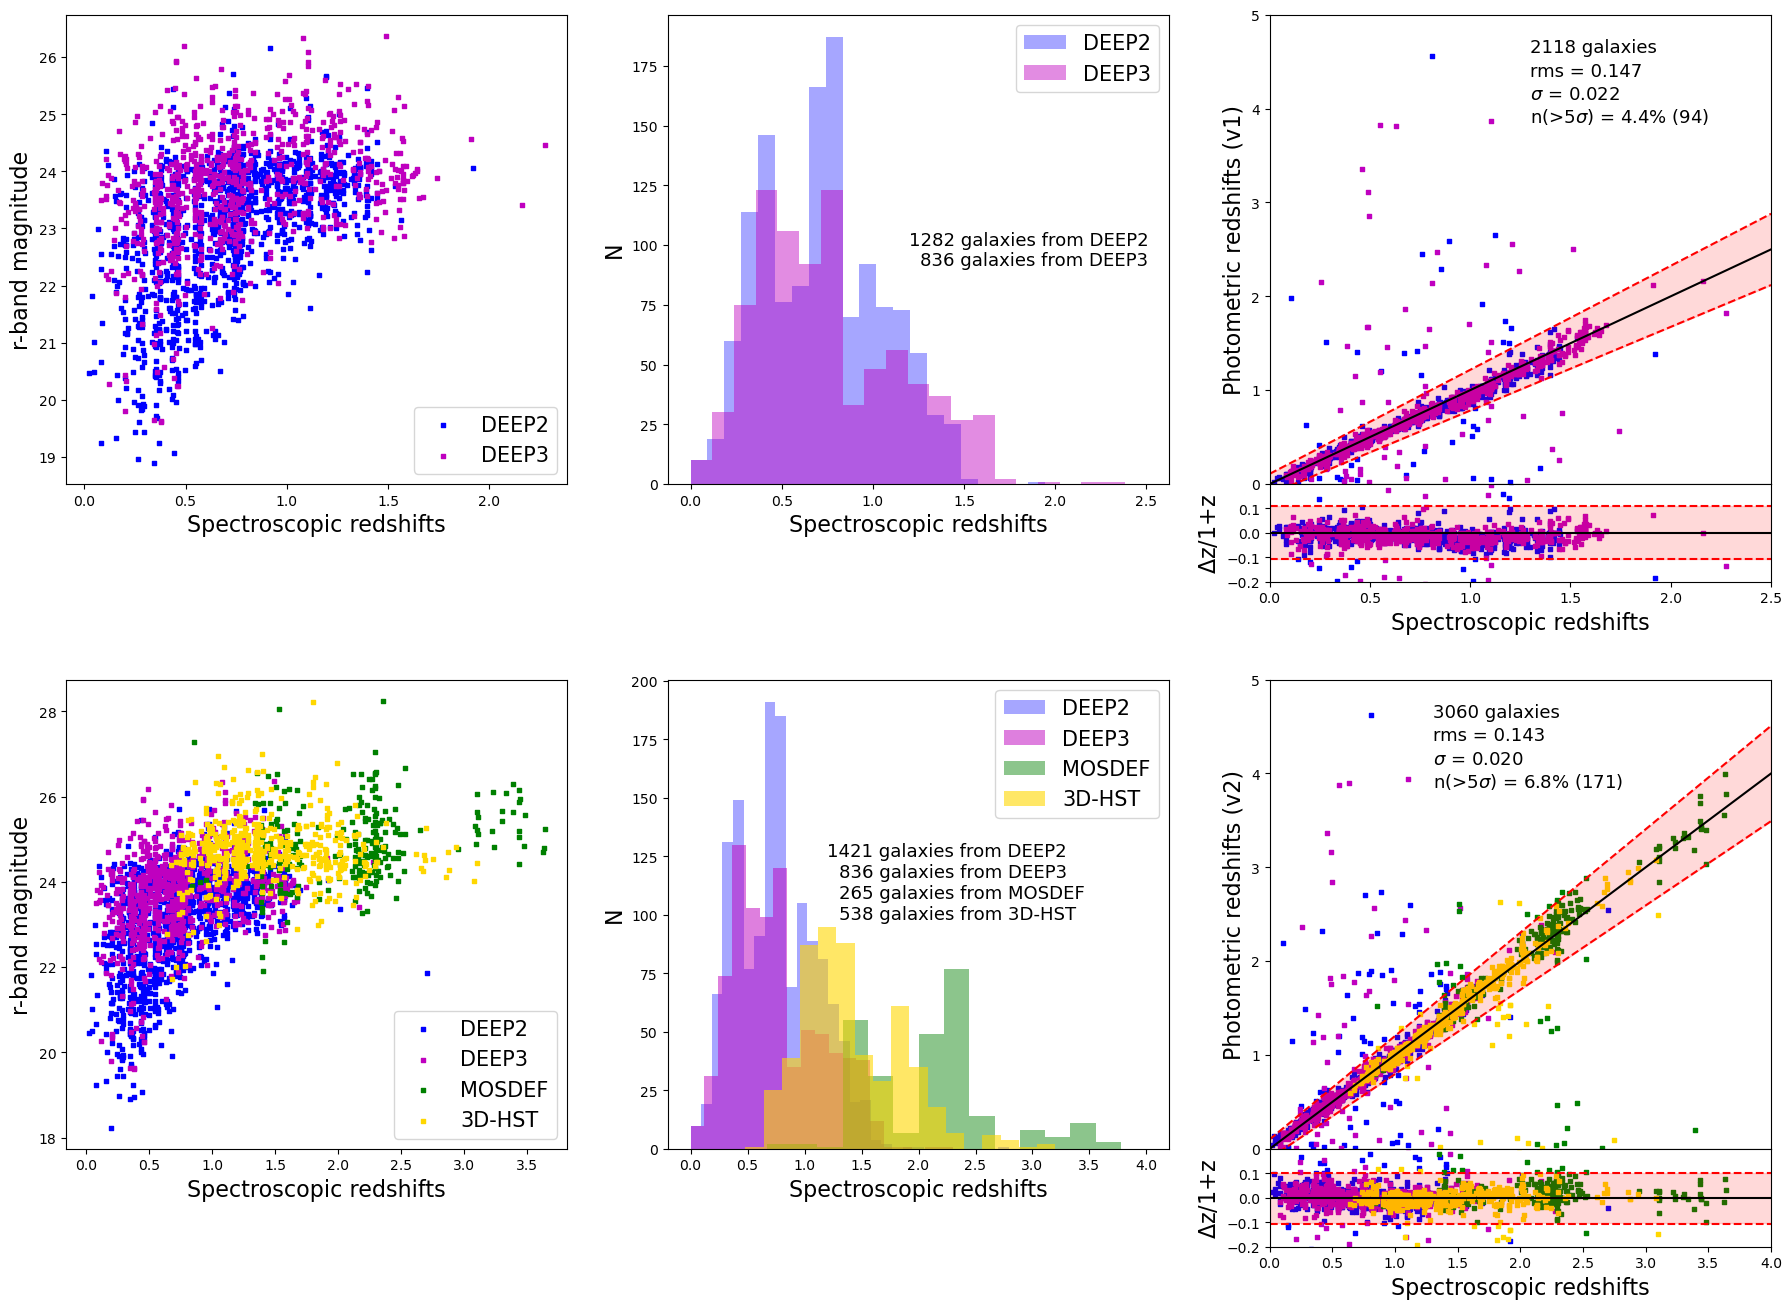

In [22]:
fig,ax= plt.subplots(5,3,figsize=(22,16),gridspec_kw={'height_ratios': 
                       [12,2.5,2.5,12,2.5]})
ax[0,0].scatter(map_d2[:,3],map_d2[:,2], color='blue', marker= 's', s= 5)
ax[0,0].scatter(map_d3[:,3],map_d3[:,2], color='m', marker= 's', s= 5)
ax[0,0].set_xlabel('Spectroscopic redshifts', fontsize = 16)
ax[0,0].set_ylabel('r-band magnitude', fontsize = 16)
ax[0,0].legend(['DEEP2','DEEP3'],loc='lower right',prop={'size':15})
ax[1,0].axis('off')
ax[1,1].axis('off')

x= np.histogram_bin_edges(deep2[:,2],bins='auto',range=(0,2.5))
ax[0,1].hist(deep2[:,2],bins=x,range=(0,2.5),histtype='barstacked',alpha=0.35,color='blue')   #zspec DEEP2
x= np.histogram_bin_edges(deep3[:,2],bins='auto',range=(0,2.5))
ax[0,1].hist(deep3[:,2],bins=x,range=(0,2.5),histtype='barstacked',alpha=0.45,color='m')      #zspec DEEP3
ax[0,1].set_xlabel('Spectroscopic redshifts', fontsize = 16)
ax[0,1].set_ylabel('N', fontsize = 16)
ax[0,1].legend(['DEEP2','DEEP3'],loc='upper right',prop={'size':15})
ax[0,1].text(1.2,100,'1282 galaxies from DEEP2',fontsize=13)
ax[0,1].text(1.26,91.5,'836 galaxies from DEEP3',fontsize=13)

ax[0,2].scatter(deep2[:,2],deep2[:,1], color='blue', marker= 's', s= 8.5)
ax[0,2].scatter(deep3[:,2],deep3[:,1], color='m', marker= 's', s= 8.5)
ax[0,2].plot(np.arange(10), color='black')
ax[0,2].plot(x1_v1,y11_v1,'--', color= 'red')
ax[0,2].plot(x1_v1,y12_v1,'--', color= 'red')
ax[0,2].fill_between(x1_v1,y11_v1,y12_v1,alpha=0.15, color='red')
ax[0,2].set_ylabel('Photometric redshifts (v1)', fontsize = 16)
ax[0,2].set_ylim(0,5)
ax[0,2].set_xlim(0,2.5)
ax[0,2].set_xticks([])
ax[0,2].text(1.3,4.60,'2118 galaxies',fontsize=13)
ax[0,2].text(1.3,4.35,'rms = 0.147',fontsize=13)
ax[0,2].text(1.3,4.10,r'$\sigma$ = 0.022',fontsize=13)
ax[0,2].text(1.3,3.85,r'n(>5$\sigma$) = 4.4% (94)',fontsize=13)
ax[1,2].scatter(deep2[:,2],dif_d2,color='blue', marker= 's', s= 8.5)
ax[1,2].scatter(deep3[:,2],dif_d3,color='m', marker= 's', s= 8.5)
ax[1,2].axhline(y=0,xmax=2.5, color='black')
x2_v1= np.arange(0,3,0.1)
y21_v1= 5*sigma_v1
y22_v1= -5*sigma_v1
ax[1,2].axhline(y=5*sigma_v1, xmax=2.5,color= 'red', linestyle='--')
ax[1,2].axhline(y=-5*sigma_v1, xmax=2.5,color= 'red', linestyle='--')
ax[1,2].set_xlabel('Spectroscopic redshifts', fontsize= 16)
ax[1,2].set_ylabel('$\Delta$z/1+z', fontsize = 16)
ax[1,2].set_ylim(-0.2,0.2)
ax[1,2].set_xlim(0,2.5)
ax[1,2].set_yticks(np.arange(-0.2,0.2,0.1))
ax[1,2].fill_between(x2_v1,y21_v1,y22_v1,alpha=0.15, color='red')

ax[2,0].axis('off')
ax[2,1].axis('off')
ax[2,2].axis('off')

ax[3,0].scatter(MAGD2_v2[:,0],MAGD2_v2[:,1], color='blue', marker= 's', s= 5)
ax[3,0].scatter(MAGD3_v2[:,0],MAGD3_v2[:,1], color='m', marker= 's', s= 5)
ax[3,0].scatter(MAGMOS_v2[:,0],MAGMOS_v2[:,1], color='green', marker= 's', s= 5)
ax[3,0].scatter(MAGHST_v2[:,0],MAGHST_v2[:,1], color='gold', marker= 's', s= 5)
ax[3,0].set_xlabel('Spectroscopic redshifts', fontsize = 16)
ax[3,0].set_ylabel('r-band magnitude', fontsize = 16)
ax[3,0].legend(['DEEP2','DEEP3','MOSDEF','3D-HST'],loc='lower right',prop={'size':15})
ax[4,0].axis('off')
ax[4,1].axis('off')

x= np.histogram_bin_edges(D2_v2,bins='auto',range=(0,4))
ax[3,1].hist(D2_v2,bins=x,range=(0,4),histtype='barstacked',alpha=0.35,color='blue')       #zspec DEEP2 
x= np.histogram_bin_edges(D3_v2,bins='auto',range=(0,4))
ax[3,1].hist(D3_v2,bins=x,range=(0,4),histtype='barstacked',alpha=0.5,color='m')           #zspec DEEP3 
x= np.histogram_bin_edges(mosdef_v2,bins='auto',range=(0,4))
ax[3,1].hist(mosdef_v2,bins=x,range=(0,4),histtype='barstacked',alpha=0.45,color='green')  #zspec MOSFIRE 
x= np.histogram_bin_edges(ZG_v2,bins='auto',range=(0,4))
ax[3,1].hist(ZG_v2,bins=x,range=(0,4),histtype='barstacked',alpha=0.6,color='gold')        #zspec 3D-HST 
ax[3,1].set_xlabel('Spectroscopic redshifts', fontsize = 16)
ax[3,1].set_ylabel('N', fontsize = 16)
ax[3,1].legend(['DEEP2','DEEP3','MOSDEF','3D-HST'],loc='upper right',prop={'size':15})
ax[3,1].text(1.2,125,'1421 galaxies from DEEP2',fontsize=13)
ax[3,1].text(1.30,116,'836 galaxies from DEEP3',fontsize=13)
ax[3,1].text(1.30,107,'265 galaxies from MOSDEF',fontsize=13)
ax[3,1].text(1.30,98,'538 galaxies from 3D-HST',fontsize=13)

ax[3,2].scatter(D2_v2,ZPD2_v2, color='blue', marker= 's', s= 8.5)
ax[3,2].scatter(D3_v2,ZPD3_v2, color='m', marker= 's', s= 8.5)
ax[3,2].scatter(mosdef_v2,ZPMOS_v2, color='green', marker= 's', s= 8.5)
ax[3,2].scatter(ZG_v2,ZPG_v2, color='gold', marker= 's', s= 8.5)
ax[3,2].plot(np.arange(10), color='black')
ax[3,2].plot(x1_v2,y11_v2,'--', color= 'red')
ax[3,2].plot(x1_v2,y12_v2,'--', color= 'red')
ax[3,2].fill_between(x1_v2,y11_v2,y12_v2,alpha=0.15, color='red')
ax[3,2].set_ylabel('Photometric redshifts (v2)', fontsize = 16)
ax[3,2].set_ylim(0,5)
ax[3,2].set_xlim(0,4)
ax[3,2].set_xticks([])
ax[3,2].text(1.3,4.60,'3060 galaxies',fontsize=13)
ax[3,2].text(1.3,4.35,'rms = 0.143',fontsize=13)
ax[3,2].text(1.3,4.10,r'$\sigma$ = 0.020',fontsize=13)
ax[3,2].text(1.3,3.85,r'n(>5$\sigma$) = 6.8% (171)',fontsize=13)
ax[4,2].scatter(D2_v2,dif_d2_v2,color='blue', marker= 's', s= 8.5)
ax[4,2].scatter(D3_v2,dif_d3_v2,color='m', marker= 's', s= 8.5)
ax[4,2].scatter(mosdef_v2,dif_mos_v2,color='green', marker= 's', s= 8.5)
ax[4,2].scatter(ZG_v2,dif_grism_v2,color='gold', marker= 's', s= 8.5)
ax[4,2].axhline(y=0,xmax=4, color='black')
x2_v2= np.arange(0,4.5,0.1)
y21_v2= 5*sigma_v2
y22_v2= -5*sigma_v2
ax[4,2].axhline(y=5*sigma_v2, xmax=4,color= 'red', linestyle='--')
ax[4,2].axhline(y=-5*sigma_v1, xmax=4,color= 'red', linestyle='--')
ax[4,2].set_xlabel('Spectroscopic redshifts', fontsize= 16)
ax[4,2].set_ylabel('$\Delta$z/1+z', fontsize = 16)
ax[4,2].set_ylim(-0.2,0.2)
ax[4,2].set_xlim(0,4)
ax[4,2].set_yticks(np.arange(-0.2,0.2,0.1))
ax[4,2].fill_between(x2_v2,y21_v2,y22_v2,alpha=0.15, color='red')

plt.subplots_adjust(hspace=0)
plt.savefig("spectroscopic_redshift.jpg",dpi=300,bbox_inches='tight')
plt.show()

In [23]:
#This function selects the best redshifts based on whether they have a spectroscopic measurement or only a photometric one.
def best (zphot,zspec):
    Z= np.column_stack((zphot,zspec))
    zb= []
    for i in range (0,np.shape(Z)[(0)]):
        if Z[:,1][i]>0:
            zb.append(Z[:,1][i])
        else:
            zb.append(Z[:,0][i])
    return zb

## Physical properties

In [24]:
class_star= np.array([registro[5] for registro in m0_mstellar])
zphot= np.array([registro[7] for registro in m0_mstellar])    #median photometric redshift (v1)
zspec= np.array([registro[74] for registro in m0_multiwave])  #spectroscopic redshift (DEEP2/3 v1)
zbest= best(zphot,zspec)                                      #best redshift, spectroscopic or photometric (v1)
mass_med= np.array([registro[19] for registro in m0_mstellar])  #stellar mass (median) without nebular emission correction
regis= np.array([25])     #band F160W
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m160= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W band
data= np.column_stack((class_star,zbest,mass_med))

#I calculate the median SFR among the 6 measures that have an exponentially declining SFH (_tau)
regis=([5,12,32,46,122])  #star formation rate SFR [Msun/yr]
SFR= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)
sfr_med=[]
for i in range (0,np.shape(SFR)[(0)]):
    lista= SFR[i,:].tolist()
    lista_updated= [value for value in lista if value != -99.0]  #It does not take into account SFR measurements at -99.0
    s= stat.median(lista_updated) #Calculate the median SFR value calculated by the different methods
    sfr_med.append(s)
sSFR_med= sfr_med/(10**data[:,2])  #median specific star formation rate [/yr]
data= np.column_stack((class_star,zbest,mass_med,sfr_med,sSFR_med,m160))
data= data[data[:,0] < 0.7] #Remove rows that have 'class_star' > 0.7
data= data[data[:,5]< 26.5] #Remove the rows with F160W >26.5
cuart_mass= perc(data[:,2])
cuart_SFR= perc(np.log10(data[:,3]))
cuart_sSFR= perc(np.log10(data[:,4]))
lowmass= data[data[:,2]<9] #It retains low-mass galaxies
nlow= np.shape(lowmass)[0] 
highmass= data[data[:,2]>=9] #It keeps galaxies with greater mass
nhigh= np.shape(highmass)[0]
print('Number of low-mass galaxies:',nlow)
print('Number of maassive galaxies:',nhigh)

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\1492814104.py:8: RuntimeWarning: invalid value encountered in log10
  m160= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W band


Quartiles (Q1,Q2,Q3): [8.33 8.84 9.37]
Interquartile range of the sample: 1.04
Quartiles (Q1,Q2,Q3): [-0.629  0.     0.61 ]
Interquartile range of the sample: 1.239
Quartiles (Q1,Q2,Q3): [-9.22 -8.86 -8.49]
Interquartile range of the sample: 0.73
Number of low-mass galaxies: 17487
Number of maassive galaxies: 12572


C:\Users\mario\AppData\Local\Temp\ipykernel_13628\2988118704.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


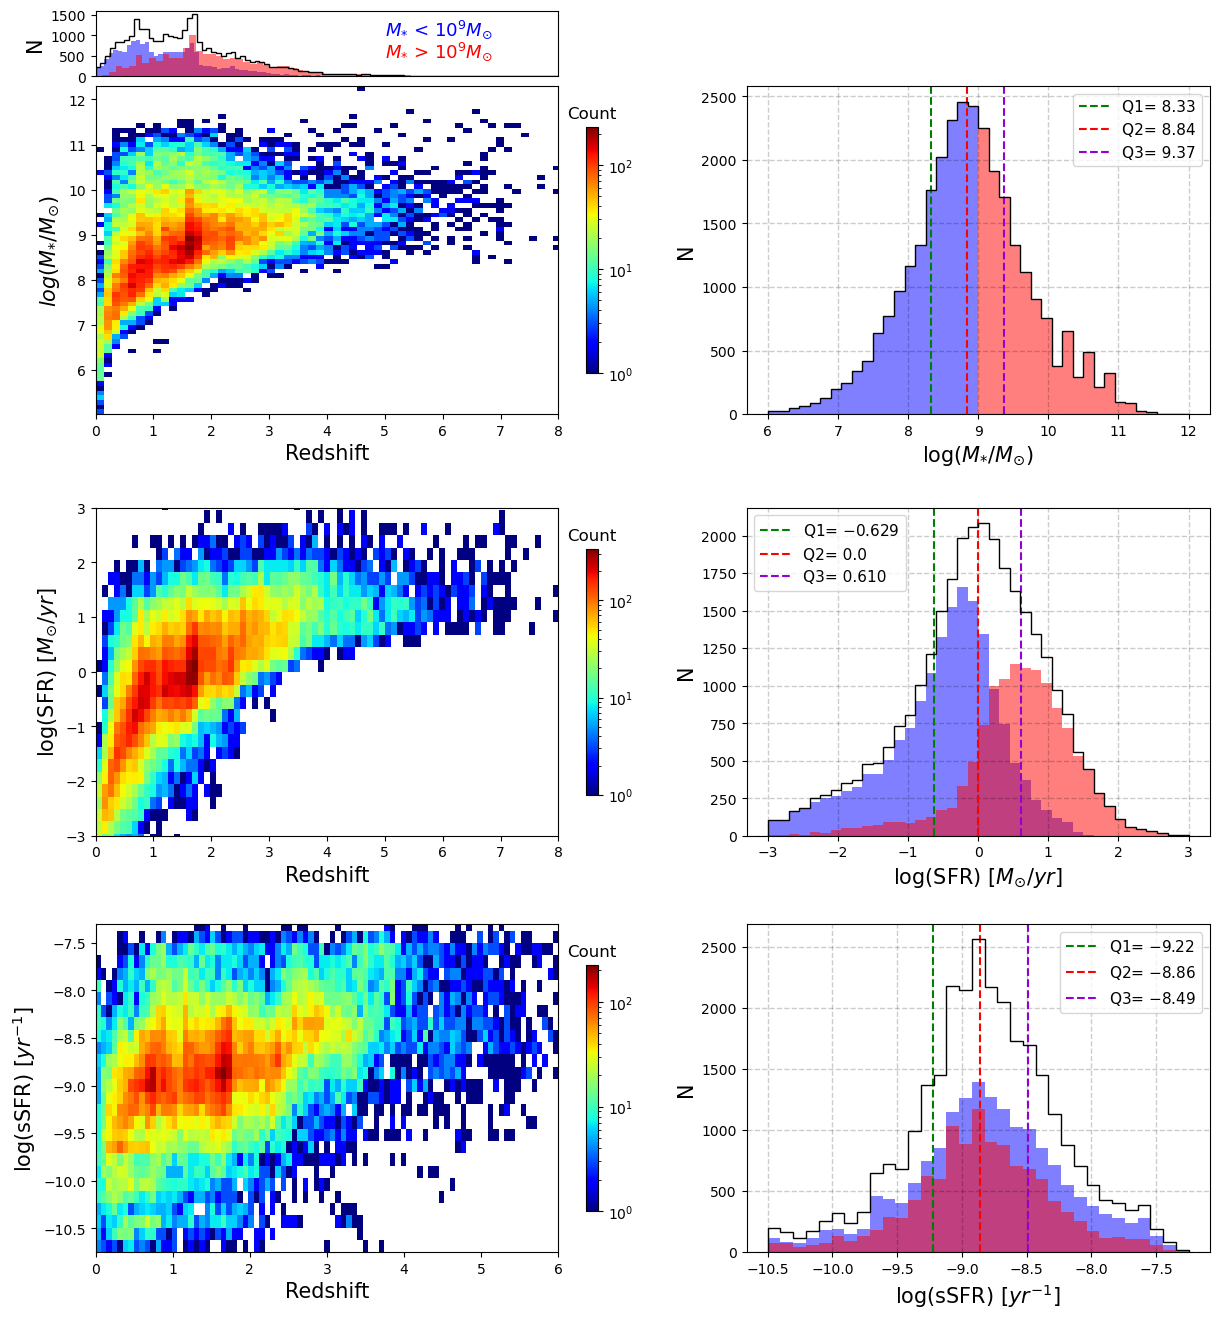

In [25]:
fig,ax= plt.subplots(6,2,figsize=(12,13),gridspec_kw={'height_ratios': 
                       [2,10,1,10,1,10],'width_ratios':[3,3]},constrained_layout= True)
ax[1,0].set_xlabel('Redshift', fontsize= 15)
ax[1,0].set_ylabel('$log(M_{*}/M_⊙)$', fontsize = 15)
ax[1,0].set_ylim(5,12)
graf= ax[1,0].hist2d(data[:,1],data[:,2],bins=70,norm= mcolors.LogNorm(vmin=None, vmax=None, clip=False),cmap='jet')
cb=fig.colorbar(graf[3],ax=ax[1,0],shrink=0.75)
cb.ax.set_title('Count')
ax[1,0].set_xlim(0,8)
ax[1,0].set_xticks(np.arange(0,9,1))

ax[0,0].set_ylabel('N', fontsize = 15)
ax[0,0].set_xlim(0,8)
ax[0,0].set_yticks(np.arange(0,3000,500))
x= np.histogram_bin_edges(lowmass[:,1],bins='fd',range=(0,8))
ax[0,0].hist(lowmass[:,1],bins=x,range=(0,8),histtype='barstacked',alpha=0.5,color='blue')
x= np.histogram_bin_edges(highmass[:,1],bins='fd',range=(0,8))
ax[0,0].hist(highmass[:,1],bins=x,range=(0,8),histtype='barstacked',alpha=0.5,color='red')
ax[0,0].text(5,1000,'$M_{*}$ < $10^{9} M_⊙$',fontsize=13,color='blue')
ax[0,0].text(5,475,'$M_{*}$ > $10^{9} M_⊙$',fontsize=13,color='red')
x= np.histogram_bin_edges(data[:,1],bins='fd',range=(0,8))
ax[0,0].hist(data[:,1],bins=x,range=(0,8),histtype='step',color='black')
ax[0,0].set_xticks([])
ax[0,1].axis('off')


ax[1,1].hist(lowmass[:,2],bins=40,range=(6,12),histtype='barstacked',alpha=0.5,color='blue')
ax[1,1].hist(highmass[:,2],bins=40,range=(6,12),histtype='barstacked',alpha=0.5,color='red')
ax[1,1].set_xlabel('log$(M_{*}/M_⊙)$', fontsize= 15)
ax[1,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[1,1].set_ylabel('N', fontsize = 15)
ax[1,1].axvline(cuart_mass[0],linewidth=1.5,linestyle='dashed',color='green')
ax[1,1].axvline(cuart_mass[1],linewidth=1.5,linestyle='dashed',color='red')
ax[1,1].axvline(cuart_mass[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[1,1].hist(data[:,2],bins=40,range=(6,12),histtype='step',color='k')    #stellar mass
ax[1,1].legend(['Q1= 8.33','Q2= 8.84','Q3= 9.37'],loc='upper right',prop={'size':11})
ax[2,0].axis('off')
ax[2,1].axis('off')

ax[3,0].set_xlabel('Redshift', fontsize= 15)
ax[3,0].set_ylabel('log(SFR) $[M_⊙/yr]$', fontsize = 15)
graf1= ax[3,0].hist2d(data[:,1],np.log10(data[:,3]),bins=95,norm= mcolors.LogNorm(vmin=None, vmax=None, clip=False),cmap='jet')
cb1=fig.colorbar(graf1[3],ax=ax[3,0],shrink=0.75)
cb1.ax.set_title('Count')
ax[3,0].set_ylim(-3,3)
ax[3,0].set_xlim(0,8)
ax[3,0].set_xticks(np.arange(0,9,1))

ax[3,1].hist(np.log10(lowmass[:,3]),bins=40,range=(-3,3),histtype='barstacked',alpha=0.5,color='blue')
ax[3,1].hist(np.log10(highmass[:,3]),bins=40,range=(-3,3),histtype='barstacked',alpha=0.5,color='red')
ax[3,1].set_xlabel('log(SFR) $[M_⊙/yr]$', fontsize= 15)
ax[3,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[3,1].set_ylabel('N', fontsize = 15)
ax[3,1].axvline(cuart_SFR[0],linewidth=1.5,linestyle='dashed',color='green')
ax[3,1].axvline(cuart_SFR[1],linewidth=1.5,linestyle='dashed',color='red')
ax[3,1].axvline(cuart_SFR[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[3,1].hist(np.log10(data[:,3]),bins=40,range=(-3,3),histtype='step',color='k')                       #SFR
ax[3,1].legend(['Q1= $-0.629$','Q2= 0.0','Q3= 0.610'],loc='upper left',prop={'size':11})
ax[4,0].axis('off')
ax[4,1].axis('off')

ax[5,0].set_xlabel('Redshift', fontsize= 15)
ax[5,0].set_ylabel('log(sSFR) [$yr^{-1}$]', fontsize = 15)
graf2= ax[5,0].hist2d(data[:,1],np.log10(data[:,4]),bins=140,norm= mcolors.LogNorm(vmin=None, vmax=None, clip=False),cmap='jet')
cb2=fig.colorbar(graf2[3],ax=ax[5,0],shrink=0.75)
cb2.ax.set_title('Count')
ax[5,0].set_ylim(-10.75,-7.3)
ax[5,0].set_xlim(0,6)
ax[5,0].set_xticks(np.arange(0,7,1))

ax[5,1].hist(np.log10(lowmass[:,4]),bins=33,range=(-10.5,-7.25),histtype='barstacked',alpha=0.5,color='blue')
ax[5,1].hist(np.log10(highmass[:,4]),bins=33,range=(-10.5,-7.25),histtype='barstacked',alpha=0.5,color='red')
ax[5,1].set_xlabel('log(sSFR) [$yr^{-1}$]', fontsize= 15)
ax[5,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[5,1].set_ylabel('N', fontsize = 15)
ax[5,1].axvline(cuart_sSFR[0],linewidth=1.5,linestyle='dashed',color='green')
ax[5,1].axvline(cuart_sSFR[1],linewidth=1.5,linestyle='dashed',color='red')
ax[5,1].axvline(cuart_sSFR[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[5,1].hist(np.log10(data[:,4]),bins=33,range=(-10.5,-7.25),histtype='step',color='k')                       #sSFR
ax[5,1].legend(['Q1= $-9.22$','Q2= $-8.86$','Q3= $-8.49$'],loc='upper right',prop={'size':11})

fig.set_constrained_layout_pads(w_pad=0.002,h_pad=0.001,wspace=0.07,hspace=0.005)
plt.savefig("physical_properties_all_catalog.jpg",dpi=300,bbox_inches='tight')
fig.show()

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\2264415063.py:3: RuntimeWarning: invalid value encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90  #Calculate the apparent magnitude in system AB
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\2264415063.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,10**5.5)


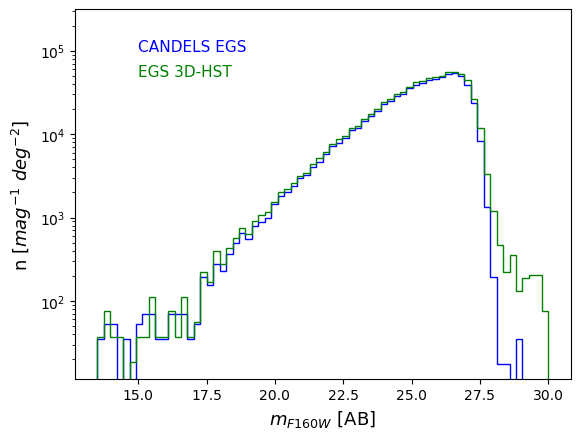

In [26]:
regis= np.array([25,59]) #EGS 3D-HST band F160W and CANDELS EGS
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m= -2.5*np.log10(flux*10**(-6))+8.90  #Calculate the apparent magnitude in system AB
regis= np.array([6])
class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
mA= np.concatenate((class_star,m), axis=1)  

plt.figure() 
plt.hist(mA[:,2],bins=70,range=(13.5,30),histtype='step',color='blue',weights=np.ones_like(mA[:,2])/0.057222222)  #area of ​​CANDELS EGS 206am^2
plt.hist(mA[:,1],bins=70,range=(13.5,30),histtype='step',color='green',weights=np.ones_like(mA[:,1])/0.053444444) #area of ​​EGS 3D-HST 192.4am^2
plt.xlabel('$m_{F160W}$ [AB]',fontsize=13)
plt.yscale('log')
plt.ylim(0,10**5.5)
plt.ylabel('n [$mag^{-1}$ $deg^{-2}$]',fontsize=13)
plt.text(15,10**5,'CANDELS EGS',fontsize=11,color='blue')
plt.text(15,10**4.7,'EGS 3D-HST',fontsize=11,color='green')
plt.savefig("magf160w.jpg",dpi=300,bbox_inches='tight')
plt.show()

In [27]:
class_star= np.array([registro[5] for registro in m0_mstellar])
zphot= np.array([registro[7] for registro in m0_mstellar])    #photometric redshift (v1)
zspec= np.array([registro[74] for registro in m0_multiwave])  #spectroscopic redshift (DEEP2/3 v1)
zbest= best(zphot,zspec)                                      #best redshift, spectroscopic or photometric (v1) 
mass_med= np.array([registro[19] for registro in m0_mstellar])  #stellar mass (median) without nebular emission correction
mass_med_neb= np.array([registro[17] for registro in m0_mstellar])  #stellar mass (median) with nebular emission correction
dif_mass_neb= mass_med_neb-mass_med
regis= np.array([25])     #band F160W
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m160= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W bands

data= np.column_stack((class_star,zbest,dif_mass_neb,mass_med,mass_med_neb,m160))
data= data[data[:,0] < 0.7] #Remove rows that have 'class_star' > 0.7
data= data[data[:,5]< 26.5] #Remove the rows with F160W >26.5

data_ord= sorted(data,key=lambda x:x[1])     #sorts the rows from smallest to largest redshift
zbest_ord= np.array([registro[1] for registro in data_ord])
dif_mass_neb_ord= np.array([registro[2] for registro in data_ord])
std_x= []
std_y= []
p= 0
u= 200
for i in range (1,150):
    n= stat.median(zbest_ord[p:u])
    std_x.append(n)
    m= stat.median(dif_mass_neb_ord[p:u])
    std_y.append(m)
    p= 200*i
    u= p+200
###################### Low-mass galaxies in the cosmic noon ##############################################################
data2= data[data[:,1]>=1.5]
data2= data2[data2[:,1]<=2.8]  #galaxies in the cosmic noon [1.5<z<2.8]
data2= data2[data2[:,3]<9]   #Galaxies in the low-mass cosmic noon M*<10^9Msun
data2_ord= sorted(data2,key=lambda x:x[1])     #sorts the rows from smallest to largest redshift
zbest2_ord= np.array([registro[1] for registro in data2_ord])
dif_mass_neb2_ord= np.array([registro[2] for registro in data2_ord])
std_x2= []
std_y2= []
p= 0
u= 34
for i in range (1,150):
    n= stat.median(zbest2_ord[p:u])
    std_x2.append(n)
    m2= stat.median(dif_mass_neb2_ord[p:u])
    std_y2.append(m2)
    p= 34*i
    u= p+34

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\425635752.py:10: RuntimeWarning: invalid value encountered in log10
  m160= -2.5*np.log10(flux*10**(-6))+8.90 #apparent magnitude in the F160W bands


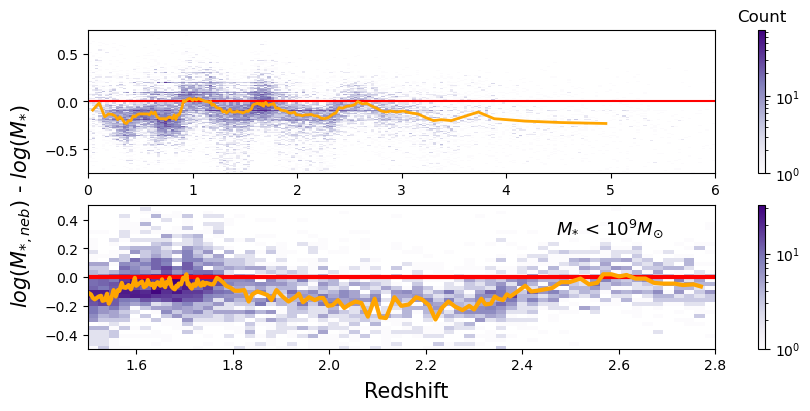

In [28]:
fig,(ax1,ax2)= plt.subplots(2,1,figsize=(8,4),gridspec_kw={'height_ratios': 
                       [2,2]},constrained_layout= True)
graf= ax1.hist2d(data[:,1],data[:,2],bins=300,norm= mcolors.LogNorm(vmin=None, vmax=None, clip=False),cmap='Purples')
cb= fig.colorbar(graf[3], ax=ax1)
cb.ax.set_title('Count')
ax1.axhline(y=0,xmax=6, color='red')
ax1.plot(std_x,std_y,linewidth=2,color='orange')
ax1.set_ylim(-0.75,0.75)
ax1.set_xlim(0,6)

graf2= ax2.hist2d(data2[:,1],data2[:,2],bins=60,norm= mcolors.LogNorm(vmin=None, vmax=None, clip=False),cmap='Purples')
cb= fig.colorbar(graf2[3], ax=ax2)
ax2.axhline(y=0,xmax=3, linewidth=3,color='red')
ax2.plot(std_x2,std_y2,linewidth=3,color='orange')
ax2.set_ylim(-0.5,0.5)
ax2.set_xlim(1.5,2.8)
ax2.text(2.47,0.3,'$M_{*}$ < $10^{9} M_⊙$',fontsize=13)

fig.supxlabel('Redshift', fontsize= 15)
fig.supylabel('$log(M_{*,neb})$ - $log(M_{*})$', fontsize = 15)
fig.set_constrained_layout_pads(hspace=0.015)
plt.savefig("nebular_emision.jpg",dpi=300,bbox_inches='tight')
plt.show()

## Inactive galaxies and galaxies with star formation within redshift ranges

In [29]:
class_star= np.array([registro[5] for registro in m0_mstellar])
zphot= np.array([registro[3] for registro in m0_photoz])      #photometric redshift (Mobasher)
zspec= np.array([registro[74] for registro in m0_multiwave])  #spectroscopic redshift (DEEP2/3 v1)
zbest= best(zphot,zspec)                                      #best redshift, spectroscopic or photometric
regis=([27])  #log stellar mass (Fontana-tau)
mass= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)  
regis= np.array([25])        #band F160W
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m_obs= -2.5*np.log10(flux*10**(-6))+8.90     #apparent magnitude observed in the F160W band
regis=([18,20,23])  #absolute magnitudes rest frame in the U, V and J bands
M_rf= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)
MV= M_rf[:,1]            #absolute magnitude rest frame in band V
U_V= M_rf[:,0]-M_rf[:,1] #color U-V_rest
V_J= M_rf[:,1]-M_rf[:,2] #color V-J_rest
regis=([12,15])  #star formation rate SFR [Msun/yr] and its chi^2 (Fontana-tau)
SFR= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)
all_gal= np.column_stack((class_star,zbest,U_V,V_J,mass,MV,SFR,m_obs)) 
all_gal= all_gal[all_gal[:,0] < 0.7]  #Remove rows that have 'class_star' > 0.7
all_gal= all_gal[all_gal[:,8] < 26.5] #Remove rows that have 'F160W' > 26.5
all_gal= all_gal[all_gal[:,4]>=0]     #eliminates galaxies with a stellar mass of < 0
all_gal= all_gal[all_gal[:,7]<5]      #eliminates galaxies with a chi^2 > 5
all_gal= all_gal[all_gal[:,4]<9]   #Remove galaxies with stellar masses above 10^9 Msol
bincn_gal= all_gal[all_gal[:,1]>=1.5]
bincn_gal= bincn_gal[bincn_gal[:,1]<=2.8] #It retains all low-mass galaxies in the cosmic-noon [1.5<=z<=2.8]
bin1_gal= all_gal[all_gal[:,1] >=0]   
bin1_gal= bin1_gal[bin1_gal[:,1] <1.5]   #It keeps all galaxies with redshift [1<=z<=1.5]
print('The total number of low-mass galaxies in the cosmic-noon [1.5<=z<=2.8] is:',np.shape(bincn_gal)[0])
print('The total number of galaxies in [0<=z<=1.5] is:',np.shape(bin1_gal)[0])
bin1_UV_QG=[]
bin1_VJ_QG=[]
bin1_cs_QG=[]
bin1_z_QG=[]
bin1_UV_SFG=[]
bin1_VJ_SFG=[]
bin1_cs_SFG=[]
bin1_z_SFG=[]
bin1_MV_QG=[]
bin1_MV_SFG=[]
bin1_mass_QG=[]
bin1_mass_SFG=[]
bin1_SFR_SFG=[]
bin1_SFR_QG=[]
for i in range (0,np.shape(bin1_gal)[0]):    
    if bin1_gal[:,2][i]>0.88*bin1_gal[:,3][i]+0.49 and bin1_gal[:,2][i]>1.3 and bin1_gal[:,3][i] <1.6:
        bin1_cs_QG.append(bin1_gal[:,0][i])
        bin1_z_QG.append(bin1_gal[:,1][i])
        bin1_UV_QG.append(bin1_gal[:,2][i])
        bin1_VJ_QG.append(bin1_gal[:,3][i])
        bin1_mass_QG.append(bin1_gal[:,4][i])
        bin1_MV_QG.append(bin1_gal[:,5][i])
        bin1_SFR_QG.append(bin1_gal[:,6][i])
    else:
        bin1_cs_SFG.append(bin1_gal[:,0][i])
        bin1_z_SFG.append(bin1_gal[:,1][i])
        bin1_UV_SFG.append(bin1_gal[:,2][i])
        bin1_VJ_SFG.append(bin1_gal[:,3][i])
        bin1_mass_SFG.append(bin1_gal[:,4][i])
        bin1_MV_SFG.append(bin1_gal[:,5][i])
        bin1_SFR_SFG.append(bin1_gal[:,6][i])
bin1_QG= np.column_stack((bin1_cs_QG,bin1_z_QG,bin1_UV_QG,bin1_VJ_QG,bin1_mass_QG,bin1_MV_QG,bin1_SFR_QG)) 
print('The number of inactive galaxies in [0<=z<=1.5] is:',np.shape(bin1_QG)[0],np.shape(bin1_QG)[0]/np.shape(bin1_gal)[0])
bin1_SFG= np.column_stack((bin1_cs_SFG,bin1_z_SFG,bin1_UV_SFG,bin1_VJ_SFG,bin1_mass_SFG,bin1_MV_SFG,bin1_SFR_SFG)) 
bin1_SFG= bin1_SFG[bin1_SFG[:,6]>0]  #eliminates galaxies with zero SFR
print('The number of star-forming galaxies in [0<=z<=1.5] is:',np.shape(bin1_SFG)[0],np.shape(bin1_SFG)[0]/np.shape(bin1_gal)[0])
x1= np.arange(0,2.5,0.01)
x1= x1[x1>=(1.3-0.49)/0.88]
x1= x1[x1<=1.6]
y1= 0.88*x1+0.49
print('-------------------------------------------------------------------------------------------------------------')
bin2_gal= all_gal[all_gal[:,1] >=1.5]   
bin2_gal= bin2_gal[bin2_gal[:,1] <=2.8] #It keeps all galaxies with redshift [1.5<z<=2.8]
print('The total number of galaxies in [1.5<z<=2.8] is:',np.shape(bin2_gal)[0])
bin2_UV_QG=[]
bin2_VJ_QG=[]
bin2_cs_QG=[]
bin2_z_QG=[]
bin2_UV_SFG=[]
bin2_VJ_SFG=[]
bin2_cs_SFG=[]
bin2_z_SFG=[]
bin2_MV_QG=[]
bin2_MV_SFG=[]
bin2_mass_QG=[]
bin2_mass_SFG=[]
bin2_SFR_SFG=[]
bin2_SFR_QG=[]
for i in range (0,np.shape(bin2_gal)[0]):    
    if bin2_gal[:,2][i]>0.88*bin2_gal[:,3][i]+0.49 and bin2_gal[:,2][i]>1.3 and bin2_gal[:,3][i]<1.6:
        bin2_cs_QG.append(bin2_gal[:,0][i]) 
        bin2_z_QG.append(bin2_gal[:,1][i])
        bin2_UV_QG.append(bin2_gal[:,2][i])
        bin2_VJ_QG.append(bin2_gal[:,3][i])
        bin2_mass_QG.append(bin2_gal[:,4][i])
        bin2_MV_QG.append(bin2_gal[:,5][i])
        bin2_SFR_QG.append(bin2_gal[:,6][i])
    else:
        bin2_cs_SFG.append(bin2_gal[:,0][i])
        bin2_z_SFG.append(bin2_gal[:,1][i])
        bin2_UV_SFG.append(bin2_gal[:,2][i])
        bin2_VJ_SFG.append(bin2_gal[:,3][i])
        bin2_mass_SFG.append(bin2_gal[:,4][i])
        bin2_MV_SFG.append(bin2_gal[:,5][i])
        bin2_SFR_SFG.append(bin2_gal[:,6][i])
bin2_QG= np.column_stack((bin2_cs_QG,bin2_z_QG,bin2_UV_QG,bin2_VJ_QG,bin2_mass_QG,bin2_MV_QG,bin2_SFR_QG)) 
print('The number of inactive galaxies in [1.5<z<=2.8] is:',np.shape(bin2_QG)[0],np.shape(bin2_QG)[0]/np.shape(bin2_gal)[0])
bin2_SFG= np.column_stack((bin2_cs_SFG,bin2_z_SFG,bin2_UV_SFG,bin2_VJ_SFG,bin2_mass_SFG,bin2_MV_SFG,bin2_SFR_SFG)) 
bin2_SFG= bin2_SFG[bin2_SFG[:,6]>0]  #eliminates galaxies with zero SFR
print('The number of star-forming galaxies in [1.5<z<=2.8] is:',np.shape(bin2_SFG)[0],np.shape(bin2_SFG)[0]/np.shape(bin2_gal)[0])
x2= np.arange(0,2.5,0.01)
x2= x2[x2>=(1.3-0.49)/0.88]
x2= x2[x2<=1.6]
y2= 0.88*x2+0.49
print('-------------------------------------------------------------------------------------------------------------')
bin4_gal= all_gal[all_gal[:,1] >2.8]   
bin4_gal= bin4_gal[bin4_gal[:,1] <=9] #It keeps all the galaxies with redshift [2.8<z<=9]
print('The total number of galaxies in [2.8<z<=9] is:',np.shape(bin4_gal)[0])
bin4_UV_QG=[]
bin4_VJ_QG=[]
bin4_cs_QG=[]
bin4_z_QG=[]
bin4_UV_SFG=[]
bin4_VJ_SFG=[]
bin4_cs_SFG=[]
bin4_z_SFG=[]
bin4_MV_QG=[]
bin4_MV_SFG=[]
bin4_mass_QG=[]
bin4_mass_SFG=[]
bin4_SFR_SFG=[]
bin4_SFR_QG=[]
for i in range (0,np.shape(bin4_gal)[0]):    
    if bin4_gal[:,2][i]>0.88*bin4_gal[:,3][i]+0.39 and bin4_gal[:,2][i]>1.3 and bin4_gal[:,3][i]<1.6:
        bin4_cs_QG.append(bin4_gal[:,0][i]) 
        bin4_z_QG.append(bin4_gal[:,1][i])
        bin4_UV_QG.append(bin4_gal[:,2][i])
        bin4_VJ_QG.append(bin4_gal[:,3][i])
        bin4_mass_QG.append(bin4_gal[:,4][i])
        bin4_MV_QG.append(bin4_gal[:,5][i])
        bin4_SFR_QG.append(bin4_gal[:,6][i])
    else:
        bin4_cs_SFG.append(bin4_gal[:,0][i])
        bin4_z_SFG.append(bin4_gal[:,1][i])
        bin4_UV_SFG.append(bin4_gal[:,2][i])
        bin4_VJ_SFG.append(bin4_gal[:,3][i])
        bin4_mass_SFG.append(bin4_gal[:,4][i])
        bin4_MV_SFG.append(bin4_gal[:,5][i])
        bin4_SFR_SFG.append(bin4_gal[:,6][i])
bin4_QG= np.column_stack((bin4_cs_QG,bin4_z_QG,bin4_UV_QG,bin4_VJ_QG,bin4_mass_QG,bin4_MV_QG,bin4_SFR_QG)) 
print('The number of inactive galaxies in [2.8<z<=9] is:',np.shape(bin4_QG)[0],np.shape(bin4_QG)[0]/np.shape(bin4_gal)[0])
bin4_SFG= np.column_stack((bin4_cs_SFG,bin4_z_SFG,bin4_UV_SFG,bin4_VJ_SFG,bin4_mass_SFG,bin4_MV_SFG,bin4_SFR_SFG)) 
bin4_SFG= bin4_SFG[bin4_SFG[:,6]>0]  #eliminates galaxies with zero SFR
print('The number of star-forming galaxies in [2.8<z<=9] is:',np.shape(bin4_SFG)[0],np.shape(bin4_SFG)[0]/np.shape(bin4_gal)[0])
x4= np.arange(0,2.5,0.01)
x4= x4[x4>=(1.3-0.39)/0.88]
x4= x4[x4<=1.6]
y4= 0.88*x4+0.39

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\4101066681.py:9: RuntimeWarning: invalid value encountered in log10
  m_obs= -2.5*np.log10(flux*10**(-6))+8.90     #apparent magnitude observed in the F160W band


The total number of low-mass galaxies in the cosmic-noon [1.5<=z<=2.8] is: 4996
The total number of galaxies in [0<=z<=1.5] is: 11143
The number of inactive galaxies in [0<=z<=1.5] is: 1259 0.11298573095216728
The number of star-forming galaxies in [0<=z<=1.5] is: 9880 0.8866552992910347
-------------------------------------------------------------------------------------------------------------
The total number of galaxies in [1.5<z<=2.8] is: 4996
The number of inactive galaxies in [1.5<z<=2.8] is: 37 0.007405924739791833
The number of star-forming galaxies in [1.5<z<=2.8] is: 4959 0.9925940752602082
-------------------------------------------------------------------------------------------------------------
The total number of galaxies in [2.8<z<=9] is: 1482
The number of inactive galaxies in [2.8<z<=9] is: 20 0.01349527665317139
The number of star-forming galaxies in [2.8<z<=9] is: 1462 0.9865047233468286


In [30]:
print('Average mass 0 < z < 1.5:', round(stat.mean(bin1_SFG[:,4]),3))
print('Uncertainty:', np.sqrt(np.var(bin1_SFG[:,4],ddof=1)))
print('Average mass 1.5 < z < 2.8:', round(stat.mean(bin2_SFG[:,4]),3))
print('Uncertainty:', round(stat.stdev(bin2_SFG[:,4]),3))
print('Average mass 2.8 < z:', round(stat.mean(bin4_SFG[:,4]),3))
print('Uncertainty:', round(stat.stdev(bin4_SFG[:,4]),3))
print('____________________________________________________________________________________________________________')
print('Average SFR 0 < z < 1.5:', round(stat.mean(np.log10(bin1_SFG[:,6])),3))
print('Uncertainty:', stat.stdev(np.log10(bin1_SFG[:,6])))
print('Average SFR 1.5 < z < 2.8:', round(stat.mean(np.log10(bin2_SFG[:,6])),3))
print('Uncertainty:', stat.stdev(np.log10(bin2_SFG[:,6])))
print('Average SFR 2.8 < z:', round(stat.mean(np.log10(bin4_SFG[:,6])),3))
print('Uncertainty:', stat.stdev(np.log10(bin4_SFG[:,6])))
print('____________________________________________________________________________________________________________')
print('Average sSFR 0 < z < 1.5:', round(stat.mean(np.log10(bin1_SFG[:,6]/10**bin1_SFG[:,4])),3))
print('Uncertainty:', stat.stdev(np.log10(bin1_SFG[:,6]/10**bin1_SFG[:,4])))
print('Average sSFR 1.5 < z < 2.8:', round(stat.mean(np.log10(bin2_SFG[:,6]/10**bin2_SFG[:,4])),3))
print('Uncertainty:', stat.stdev(np.log10(bin2_SFG[:,6]/10**bin2_SFG[:,4])))
print('Average sSFR 2.8 < z:', round(stat.mean(np.log10(bin4_SFG[:,6]/10**bin4_SFG[:,4])),3))
print('Uncertainty:', stat.stdev(np.log10(bin4_SFG[:,6]/10**bin4_SFG[:,4])))
print('____________________________________________________________________________________________________________')
print('Average U-V 0 < z < 1.5:', round(stat.mean(bin1_SFG[:,2]),3))
print('Uncertainty:', stat.stdev(bin1_SFG[:,2]))
print('Average U-V 1.5 < z < 2.8:', round(stat.mean(bin2_SFG[:,2]),3))
print('Uncertainty:', stat.stdev(bin2_SFG[:,2]))
print('Average U-V 2.8 < z:', round(stat.mean(bin4_SFG[:,2]),3))
print('Uncertainty:', stat.stdev(bin4_SFG[:,2]))

Average mass 0 < z < 1.5: 8.1
Uncertainty: 0.5861797017481458
Average mass 1.5 < z < 2.8: 8.571
Uncertainty: 0.352
Average mass 2.8 < z: 8.55
Uncertainty: 0.406
____________________________________________________________________________________________________________
Average SFR 0 < z < 1.5: -0.525
Uncertainty: 0.9050208481114846
Average SFR 1.5 < z < 2.8: 0.021
Uncertainty: 0.6177878174078187
Average SFR 2.8 < z: 0.697
Uncertainty: 0.7195899173005238
____________________________________________________________________________________________________________
Average sSFR 0 < z < 1.5: -8.625
Uncertainty: 0.8584272840291439
Average sSFR 1.5 < z < 2.8: -8.55
Uncertainty: 0.7123526240772245
Average sSFR 2.8 < z: -7.853
Uncertainty: 0.7351109329463861
____________________________________________________________________________________________________________
Average U-V 0 < z < 1.5: 0.868
Uncertainty: 0.24494299290028512
Average U-V 1.5 < z < 2.8: 0.673
Uncertainty: 0.21827523745949615
Av

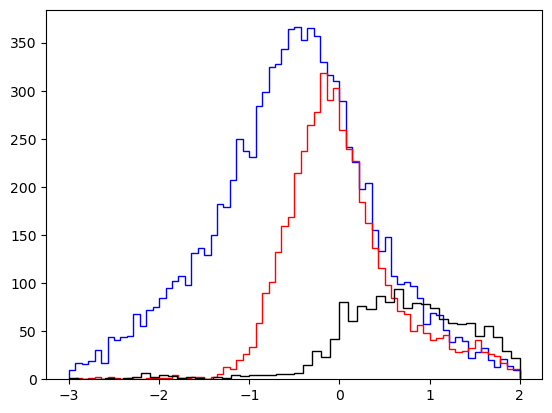

In [31]:
plt.figure()
plt.hist(np.log10(bin1_SFG[:,6]),bins=70,range=(-3,2),histtype='step',color='blue') 
plt.hist(np.log10(bin2_SFG[:,6]),bins=70,range=(-3,2),histtype='step',color='red') 
plt.hist(np.log10(bin4_SFG[:,6]),bins=50,range=(-3,2),histtype='step',color='black')
plt.show()

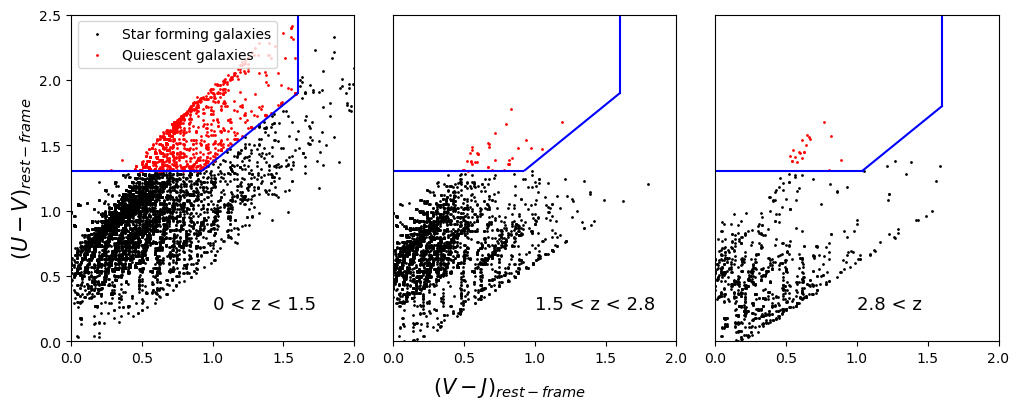

In [32]:
fig,ax= plt.subplots(1,3,figsize=(10,4),gridspec_kw={'width_ratios': 
                     [3,3,3]},constrained_layout= True)
ax[0].scatter(bin1_SFG[:,3],bin1_SFG[:,2],s=1,color='black')
ax[0].scatter(bin1_QG[:,3],bin1_QG[:,2],s=1,color='red')
ax[0].legend(['Star forming galaxies','Quiescent galaxies'],loc='upper left',prop={'size':10})
ax[0].set_xlim(0,2)
ax[0].set_ylim(0,2.5)
ax[0].axhline(y=1.3,xmax=0.46,color='blue')
ax[0].axvline(x=1.6,ymin=0.76,color='blue')
ax[0].plot(x1,y1,color='blue')
ax[0].text(1,0.25,'0 < z < 1.5',fontsize=13)
ax[0].set_ylabel('$(U-V)_{rest-frame}$',fontsize = 15)

ax[1].scatter(bin2_SFG[:,3],bin2_SFG[:,2],s=1,color='black')
ax[1].scatter(bin2_QG[:,3],bin2_QG[:,2],s=1,color='red')
ax[1].set_xlim(0,2)
ax[1].set_ylim(0,2.5)
ax[1].axhline(y=1.3,xmax=0.46,color='blue')
ax[1].axvline(x=1.6,ymin=0.76,color='blue')
ax[1].plot(x2,y2,color='blue')
ax[1].text(1,0.25,'1.5 < z < 2.8',fontsize=13)
ax[1].set_yticks([])

ax[2].scatter(bin4_SFG[:,3],bin4_SFG[:,2],s=1,color='black')
ax[2].scatter(bin4_QG[:,3],bin4_QG[:,2],s=1,color='red')
ax[2].set_xlim(0,2)
ax[2].set_ylim(0,2.5)
ax[2].axhline(y=1.3,xmax=0.52,color='blue')
ax[2].axvline(x=1.6,ymin=0.72,color='blue')
ax[2].plot(x4,y4,color='blue')
ax[2].text(1,0.25,'2.8 < z',fontsize=13)
ax[2].set_yticks([])

fig.supxlabel('$(V-J)_{rest-frame}$',fontsize = 15)
fig.set_constrained_layout_pads(w_pad=0.002,h_pad=0.05,wspace=0.05,hspace=1)
plt.savefig("UVJ.jpg",dpi=300,bbox_inches='tight')
plt.show()

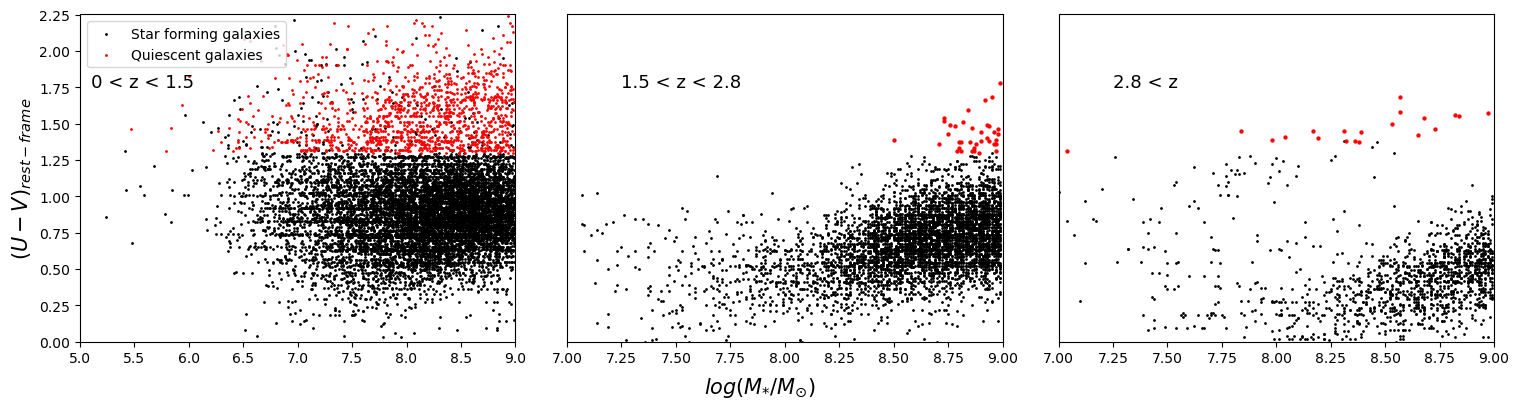

In [33]:
fig,ax= plt.subplots(1,3,figsize=(15,4),gridspec_kw={'width_ratios': 
                     [3,3,3]},constrained_layout= True)
ax[0].scatter(bin1_SFG[:,4],bin1_SFG[:,2],s=1,color='black')
ax[0].scatter(bin1_QG[:,4],bin1_QG[:,2],s=1,color='red')
ax[0].legend(['Star forming galaxies','Quiescent galaxies'],loc='upper left',prop={'size':10})
ax[0].set_xlim(5,9)
ax[0].set_ylim(0,2.25)
ax[0].text(5.1,1.75,'0 < z < 1.5',fontsize=13)
ax[0].set_ylabel('$(U-V)_{rest-frame}$',fontsize = 15)

ax[1].scatter(bin2_SFG[:,4],bin2_SFG[:,2],s=1,color='black')
ax[1].scatter(bin2_QG[:,4],bin2_QG[:,2],s=4.5,color='red')
ax[1].set_xlim(7,9)
ax[1].set_ylim(0,2.25)
ax[1].text(7.25,1.75,'1.5 < z < 2.8',fontsize=13)
ax[1].set_yticks([])

ax[2].scatter(bin4_SFG[:,4],bin4_SFG[:,2],s=1,color='black')
ax[2].scatter(bin4_QG[:,4],bin4_QG[:,2],s=4.5,color='red')
ax[2].set_xlim(7,9)
ax[2].set_ylim(0,2.25)
ax[2].text(7.25,1.75,'2.8 < z',fontsize=13)
ax[2].set_yticks([])

fig.supxlabel('$log(M_{*}/M_⊙)$',fontsize = 15)
fig.set_constrained_layout_pads(w_pad=0.002,h_pad=0.05,wspace=0.05,hspace=0.015)
plt.savefig("uv_stellarmass.jpg",dpi=300,bbox_inches='tight')
plt.show()

## Main sequence of star formation in galaxies

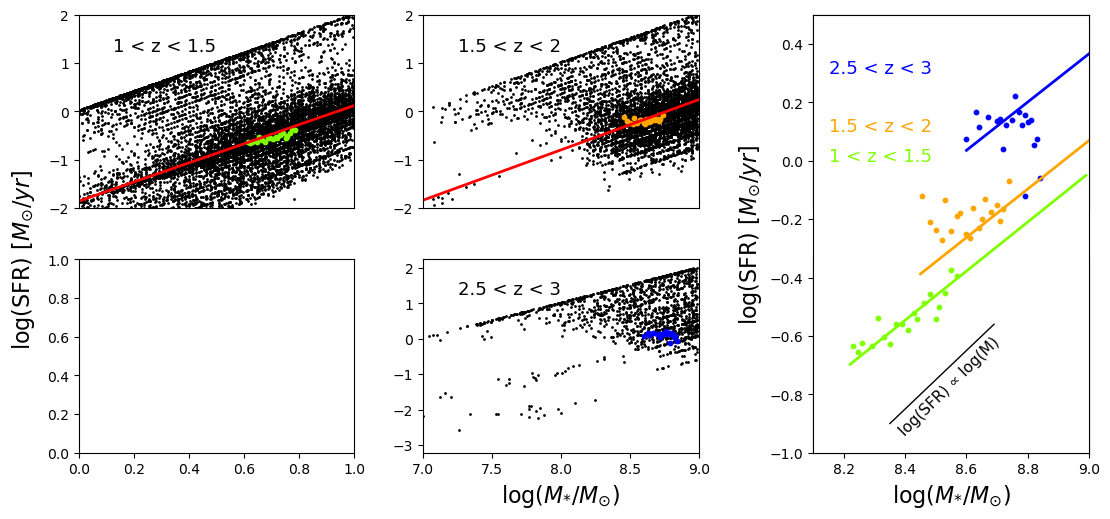

In [34]:
x= np.arange(7,9,0.001)
def pol(x,rango):
    if rango == 1:
        y= 0.99*(x-10.2)+1.31
    elif rango == 2:
        y= 1.04*(x-10.2)+1.49
    elif rango == 3:
        y= 0.91*(x-10.2)+1.62
    elif rango == 4:
        y= 0.197*x-1.440
    return y

databin1= np.column_stack((bin1_SFG[:,4],np.log10(bin1_SFG[:,6])))
databin1_ord= sorted(databin1,key=lambda x:x[0])                   #Order the rows from lowest to highest stellar mass
mass1_ord= np.array([registro[0] for registro in databin1_ord])
sfr1_ord= np.array([registro[1] for registro in databin1_ord])
databin1_ord= np.column_stack((mass1_ord,sfr1_ord))
databin1_ord= databin1_ord[databin1_ord[:,0]>=8.22]
databin1_ord= databin1_ord[databin1_ord[:,1]<=0.5]
databin1_ord= databin1_ord[databin1_ord[:,1]>=-1.5]
mass1_ord= databin1_ord[:,0]
sfr1_ord= databin1_ord[:,1]
std1_x= []
std1_y= []
p= 0
u= 116
for i in range (1,20):
    n= stat.median(mass1_ord[p:u])
    std1_x.append(n)
    m= stat.median(sfr1_ord[p:u])
    std1_y.append(m)
    p= 116*i
    u= p+116

databin2= np.column_stack((bin2_SFG[:,4],np.log10(bin2_SFG[:,6])))
databin2_ord= sorted(databin2,key=lambda x:x[0])                   #Order the rows from lowest to highest stellar mass
mass2_ord= np.array([registro[0] for registro in databin2_ord])
sfr2_ord= np.array([registro[1] for registro in databin2_ord])
databin2_ord= np.column_stack((mass2_ord,sfr2_ord))
databin2_ord= databin2_ord[databin2_ord[:,0]>=8.45]
databin2_ord= databin2_ord[databin2_ord[:,1]<=1.7]
databin2_ord= databin2_ord[databin2_ord[:,1]>=-1.75]
mass2_ord= databin2_ord[:,0]
sfr2_ord= databin2_ord[:,1]
std2_x= []
std2_y= []
p= 0
u= 96
for i in range (1,20):
    n= stat.median(mass2_ord[p:u])
    std2_x.append(n)
    m= stat.median(sfr2_ord[p:u])
    std2_y.append(m)
    p= 96*i
    u= p+96
   
databin4= np.column_stack((bin4_SFG[:,4],np.log10(bin4_SFG[:,6])))
databin4_ord= sorted(databin4,key=lambda x:x[0])                   #Order the rows from lowest to highest stellar mass
mass4_ord= np.array([registro[0] for registro in databin4_ord])
sfr4_ord= np.array([registro[1] for registro in databin4_ord])
databin4_ord= np.column_stack((mass4_ord,sfr4_ord))
databin4_ord= databin4_ord[databin4_ord[:,0]>=8.60] 
databin4_ord= databin4_ord[databin4_ord[:,1]<=0.35]
databin4_ord= databin4_ord[databin4_ord[:,1]>=-0.15]
mass4_ord= databin4_ord[:,0]
sfr4_ord= databin4_ord[:,1]
std4_x= []
std4_y= []
p= 0
u= 7
for i in range (1,20):
    n= stat.median(mass4_ord[p:u])
    std4_x.append(n)
    m= stat.median(sfr4_ord[p:u])
    std4_y.append(m)
    p= 7*i
    u= p+7
    
x1= np.arange(8.22,9,0.01)
x2= np.arange(8.45,9,0.01)
x3= np.arange(8.55,9,0.01)
x4= np.arange(8.6,9,0.01)
xunity= np.arange(8.35,8.7,0.01)
yunity= xunity-9.25

fig,ax= plt.subplots(2,3,figsize=(11,5),gridspec_kw={'width_ratios': 
                     [4,4,4],'height_ratios':[3,3]},constrained_layout= True)
ax[0,0].scatter(bin1_SFG[:,4],np.log10(bin1_SFG[:,6]),s=1,color='black')
ax[0,0].plot(x,pol(x,1),linewidth=2,color='red')
ax[0,0].scatter(std1_x,std1_y,s=10,color='chartreuse')
ax[0,0].set_xticks([])
ax[0,0].set_ylim(-2,2)
ax[0,0].set_xlim(7,9)
ax[0,0].text(7.25,1.25,'1 < z < 1.5',fontsize=13)

ax[0,1].scatter(bin2_SFG[:,4],np.log10(bin2_SFG[:,6]),s=1,color='black')
ax[0,1].plot(x,pol(x,2),linewidth=2,color='red')
ax[0,1].scatter(std2_x,std2_y,s=10,color='orange')
ax[0,1].set_xticks([])
ax[0,1].set_ylim(-2,2)
ax[0,1].set_xlim(7,9)
ax[0,1].text(7.25,1.25,'1.5 < z < 2',fontsize=13)

ax[1,1].scatter(bin4_SFG[:,4],np.log10(bin4_SFG[:,6]),s=1,color='black')
ax[1,1].scatter(std4_x,std4_y,s=10,color='blue')
ax[1,1].set_xlim(7,9)
ax[1,1].set_xlabel('log$(M_{*}/M_⊙)$',fontsize = 16)
ax[1,1].text(7.25,1.25,'2.5 < z < 3',fontsize=13)

ax[0,2].set_xticks([])
ax[0,2].set_yticks([])
ax[1,2].set_xticks([])
ax[1,2].set_yticks([])
gs = ax[0, 2].get_gridspec()
axbig = fig.add_subplot(gs[0:,-1])
axbig.scatter(std1_x,std1_y,s=10,color='chartreuse')
axbig.scatter(std2_x,std2_y,s=10,color='orange')
axbig.scatter(std4_x,std4_y,s=10,color='blue')
axbig.plot(x1,0.840*x1-7.602,linewidth=2,color='chartreuse')
axbig.plot(x2,0.830*x2-7.401,linewidth=2,color='orange')
axbig.plot(x4,0.826*x4-7.068,linewidth=2,color='blue')
axbig.plot(xunity,yunity,linewidth=1,color='black')
axbig.text(8.37,-0.94,'log(SFR) ∝ log(M)',fontsize=11,color='black',rotation=44.5)
axbig.set_ylim(-1,0.5)
axbig.set_xlim(8.1,9)
axbig.set_ylabel('log(SFR) $[M_⊙/yr]$',fontsize = 16)
axbig.set_xlabel('log$(M_{*}/M_⊙)$',fontsize = 16)
axbig.text(8.15,0,'1 < z < 1.5',fontsize=13,color='chartreuse')
axbig.text(8.15,0.10,'1.5 < z < 2',fontsize=13,color='orange')
axbig.text(8.15,0.30,'2.5 < z < 3',fontsize=13,color='blue')

fig.supylabel('log(SFR) $[M_⊙/yr]$',fontsize = 16)
fig.set_constrained_layout_pads(w_pad=0.05,h_pad=0.001,wspace=0.075,hspace=0.075)
plt.savefig("main_sequence.jpg",dpi=300,bbox_inches='tight')
plt.show()

## Photometric and physical properties of our sample of low-mass star-forming galaxies in the cosmic noon

In [35]:
####################################### Color indices and apparent magnitudes ######################################################################
class_star= np.array([registro[5] for registro in m0_mstellar]) #class-star
zphot= np.array([registro[3] for registro in m0_photoz])      #photometric redshift (Mobasher)
zspec= np.array([registro[74] for registro in m0_multiwave])  #spectroscopic redshift (DEEP2/3 v1)
zbest= best(zphot,zspec)                                      #best redshift, spectroscopic (if available) or photometric
regis=([27])  
mass= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)  #log(M*/Msun) (Fontana-tau)
regis=([12,15])  #SFR [Msun/yr] and its chi^2 (Fontana-tau)
SFR= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)

regis= np.array([25,7,15,21,25,27,31,17])        #bands F160W,u',z',F125W,F160W,J,Ks,F606W
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m= -2.5*np.log10(flux*10**(-6))+8.90     #observed apparent magnitudes
mf160= m[:,0]   #apparent magnitude in the F160W band
A= np.column_stack((class_star,zbest,m,mass,SFR))  
A= A[A[:,0]<0.7]                         #Remove rows that have 'CLASS_STAR' > 0.7
A= A[A[:,2]<26.5]                        #Remove rows that have 'F160W' > 26.5
A= A[A[:,1]<=2.8]                        #It keeps galaxies in the cosmic noon [1.5<z<2.8]
A= A[A[:,1]>=1.5]
A= A[A[:,10]<9]                       #It is left with low-mass galaxies M < 10^9Msun
A= A[A[:,10]>=0]        #It eliminates galaxies with a stellar mass of -99.0
A= A[A[:,12]<5]         #eliminates galaxies with chi^2 > 5
print('The minimum mass is:',np.min(A[:,10]))
color1= A[:,3]-A[:,4]  #color u-z
color2= A[:,5]-A[:,6]  #color F125W-F160W
mf606= A[:,9]          #apparent magnitude in the F606W band (visual, V)
mf125= A[:,5]          #apparent magnitude in the F125W band (NIR, J)
indcolor= np.column_stack((color1,color2,mf606,mf125))
print('Total number of low-mass galaxies in the cosmic noon=',np.shape(indcolor)[(0)])
#################################### Rest-Frame Absolute Magnitudes ##########################################################
regis=([19,20,23])  #absolute rest-frame magnitudes in the B, V and J bands
M_rf= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)
B= np.column_stack((class_star,zbest,mass,mf160,M_rf,SFR)) 
B= B[B[:,0]<0.7]                         #Remove rows that have 'CLASS_STAR' > 0.7
B= B[B[:,3]<26.5]                        #Remove rows that have 'F160W' > 26.5
B= B[B[:,1]<=2.8]                        #It keeps galaxies in the cosmic noon [1.5<z<2.8]
B= B[B[:,1]>=1.5]
B= B[B[:,2]<9]                       #It is left with low-mass galaxies M < 10^9Msun
B= B[B[:,2]>=0]        #It eliminates galaxies with a stellar mass of -99.0
B= B[B[:,8]<5]         #eliminates galaxies with chi^2 > 5
print('Total number of low-mass galaxies in the cosmic noon=',np.shape(B)[(0)])
################################### Redshift, Age and Distance Module ######################################################
cosmo=FlatLambdaCDM(H0=67.3, Om0=0.315)
edad= cosmo.age(zbest).value                 #age of the universe [Gyr]
dL= cosmo.luminosity_distance(zbest).value   #distance by brightness [Mpc]
mu= 5*(np.log10(dL)+5)                       #distance module
C= np.column_stack((class_star,zbest,mass,mf160,edad,mu,SFR))
C= C[C[:,0]<0.7]                         #Remove rows that have 'CLASS_STAR' > 0.7
C= C[C[:,3]<26.5]                        #Remove rows that have 'F160W' > 26.5
C= C[C[:,1]<=2.8]                        #It keeps galaxies in the cosmic noon [1.5<z<2.8]
C= C[C[:,1]>=1.5]
C= C[C[:,2]<9]                       #It is left with low-mass galaxies M < 10^9Msun
C= C[C[:,2]>=0]        #It eliminates galaxies with a stellar mass of -99.0
C= C[C[:,7]<5]         #eliminates galaxies with chi^2 > 5
print('Total number of low-mass galaxies in the cosmic noon=',np.shape(C)[(0)])
########################### Stellar mass, star formation rate, size, and specific SFR #########################################
regis= np.array([63])
l= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,6,regis)   #radio 50% [px]
esc= 0.06     #WFC3-IR detector plate scale in the F160W band [arcsec/px]
r= esc*2*l    #Diameters 50% [arcsec]
kpc_arcmin= cosmo.kpc_proper_per_arcmin(zbest).value  #[kpc/arcmin]
kpc_arcseg= kpc_arcmin/60   #[kpc/arcseg]
tam= r[:,0]*kpc_arcseg      #Size (using D_50) [kpc]
sSFR= SFR/(10**mass)          #median specific star formation rate [/yr]
D= np.column_stack((class_star,zbest,mass,mf160,SFR,tam,sSFR))
D= D[D[:,0]<0.7]                         
D= D[D[:,3]<26.5]                        
D= D[D[:,1]<=2.8]                        
D= D[D[:,1]>=1.5]
D= D[D[:,2]<9]                       
D= D[D[:,2]>=0]        
D= D[D[:,5]<5]         
print('Total number of low-mass galaxies in the cosmic noon=',np.shape(D)[(0)])
########################################## Quartiles #########################################################################
cuart_uz= perc(indcolor[:,0])
cuart_125160= perc(indcolor[:,1])
cuart_mf606= perc(indcolor[:,2])
print('--------------------------------------------------------------------------------------------')
cuart_mf125= perc(indcolor[:,3])
cuart_MV= perc(B[:,5])
cuart_MJ= perc(B[:,6])
print('--------------------------------------------------------------------------------------------')
cuart_z= perc(C[:,1])
cuart_edad= perc(C[:,4])
cuart_mu= perc(C[:,5])
print('--------------------------------------------------------------------------------------------')
cuart_mass= perc(D[:,2])
cuart_SFR= perc(np.log10(D[:,4]))
cuart_tam= perc(D[:,6])
cuart_sSFR= perc(np.log10(D[:,7]))

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3559498729.py:13: RuntimeWarning: divide by zero encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90     #observed apparent magnitudes
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3559498729.py:13: RuntimeWarning: invalid value encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90     #observed apparent magnitudes
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\3559498729.py:46: RuntimeWarning: divide by zero encountered in log10
  mu= 5*(np.log10(dL)+5)                       #distance module


The minimum mass is: 6.23
Total number of low-mass galaxies in the cosmic noon= 4996
Total number of low-mass galaxies in the cosmic noon= 4996
Total number of low-mass galaxies in the cosmic noon= 4996
Total number of low-mass galaxies in the cosmic noon= 4996
Quartiles (Q1,Q2,Q3): [-0.001  0.385  0.792]
Interquartile range of the sample: 0.793
Quartiles (Q1,Q2,Q3): [0.049 0.262 0.492]
Interquartile range of the sample: 0.443
Quartiles (Q1,Q2,Q3): [26.015 26.516 26.975]
Interquartile range of the sample: 0.96
--------------------------------------------------------------------------------------------
Quartiles (Q1,Q2,Q3): [25.475 25.968 26.448]
Interquartile range of the sample: 0.973
Quartiles (Q1,Q2,Q3): [-19.27 -18.81 -18.35]
Interquartile range of the sample: 0.92
Quartiles (Q1,Q2,Q3): [-19.49 -19.04 -18.53]
Interquartile range of the sample: 0.96
--------------------------------------------------------------------------------------------
Quartiles (Q1,Q2,Q3): [1.65 1.98 2.3 ]
Int

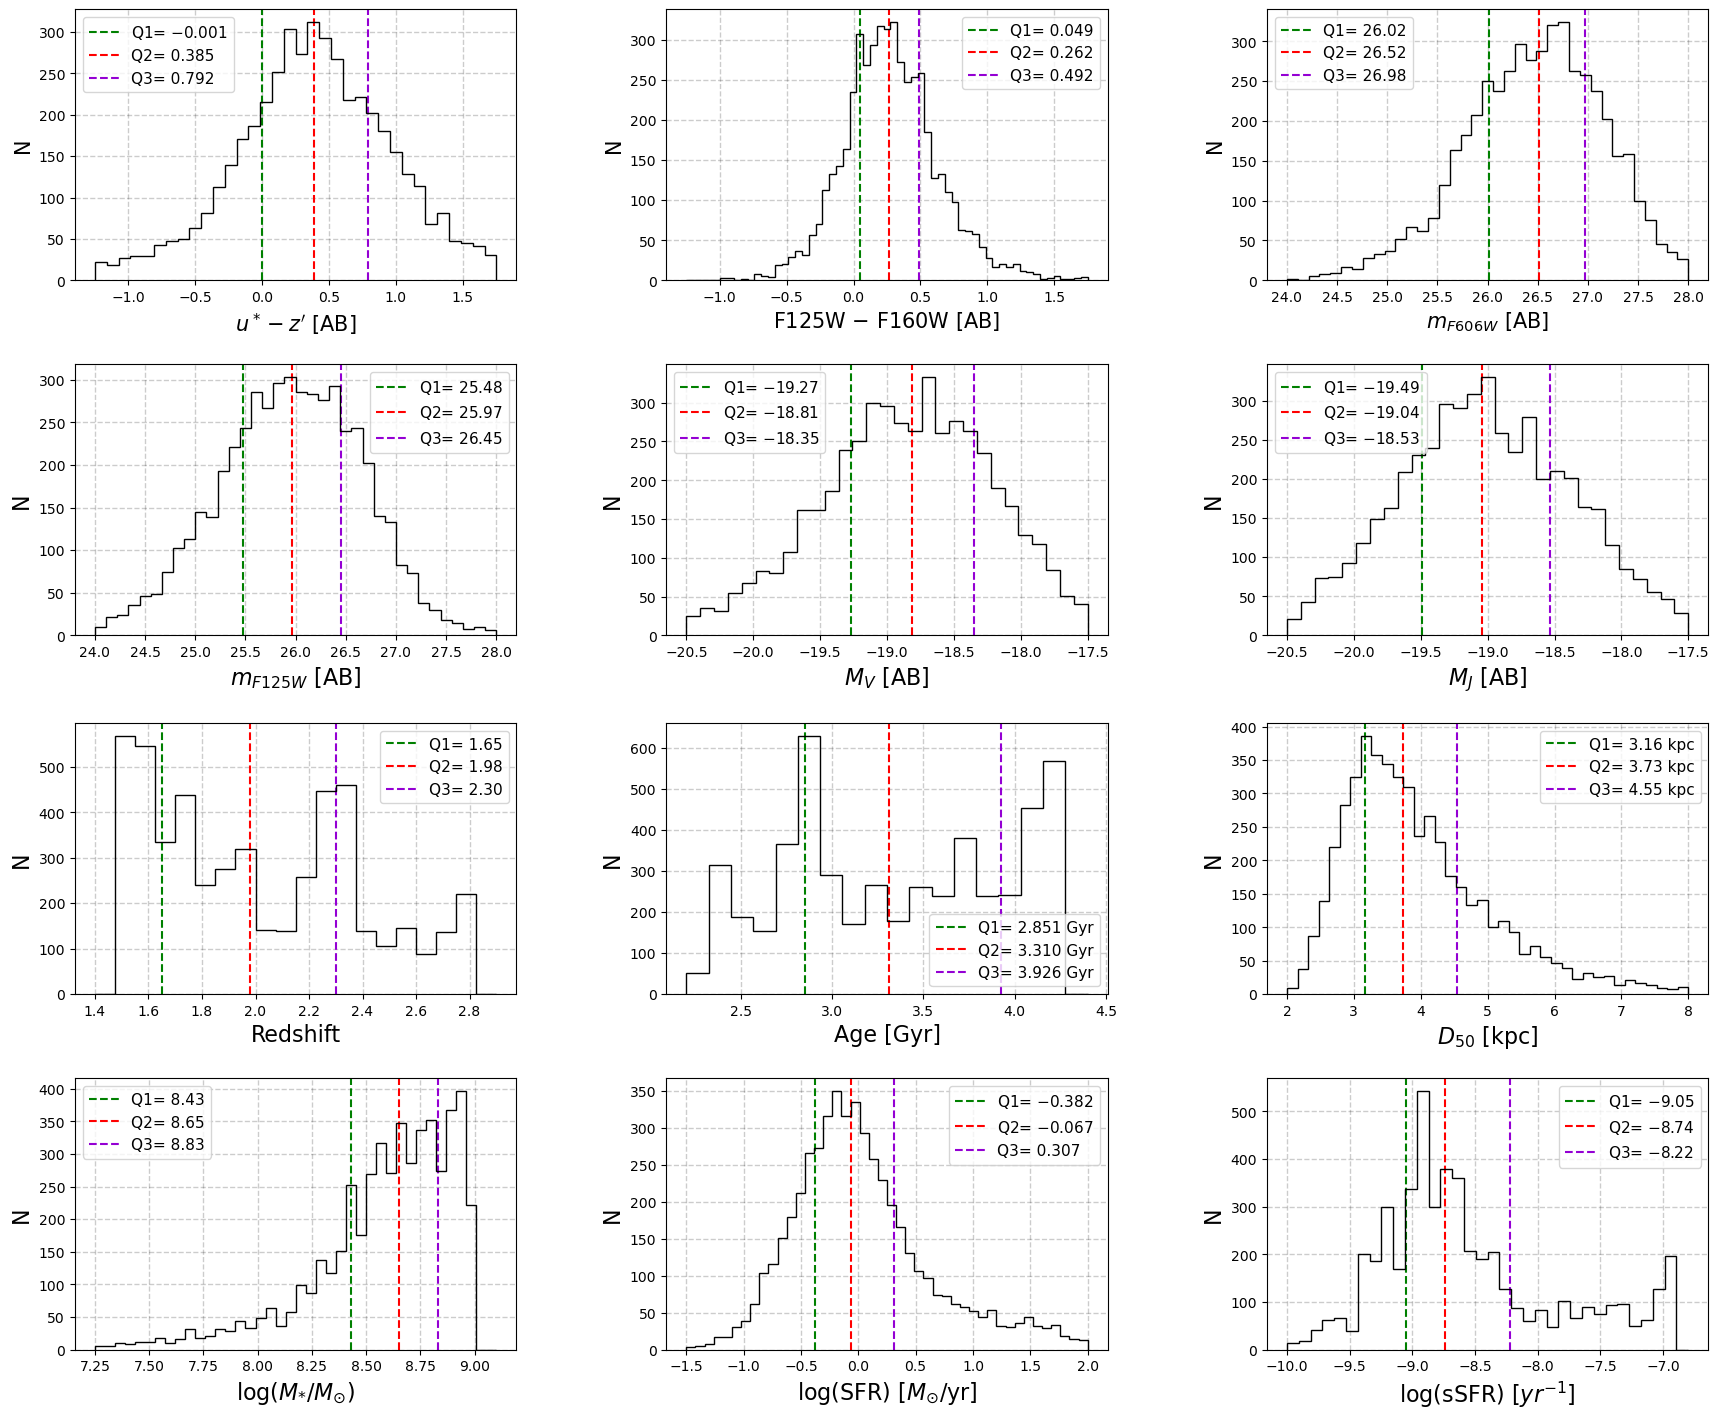

In [36]:
fig,ax= plt.subplots(4,3,figsize=(17,14),gridspec_kw={'width_ratios': 
                     [5,5,5],'height_ratios':[3,3,3,3]},constrained_layout= True)
x= np.histogram_bin_edges(indcolor[:,0],bins='fd',range=(-1.25,1.75)) 
ax[0,0].axvline(cuart_uz[0],linewidth=1.5,linestyle='dashed',color='green')
ax[0,0].axvline(cuart_uz[1],linewidth=1.5,linestyle='dashed',color='red')
ax[0,0].axvline(cuart_uz[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[0,0].hist(indcolor[:,0],bins=x,range=(-1.25,1.75),histtype='step',color='k')      #color u-z
ax[0,0].legend(['Q1= $-0.001$','Q2= 0.385','Q3= 0.792'],loc='upper left',prop={'size':11})
ax[0,0].set_xlabel('$u^*-z\'$ [AB]', fontsize= 15)
ax[0,0].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[0,0].set_ylabel('N', fontsize = 15)

x= np.histogram_bin_edges(indcolor[:,1],bins='fd',range=(-1.25,1.75))
ax[0,1].axvline(cuart_125160[0],linewidth=1.5,linestyle='dashed',color='green')
ax[0,1].axvline(cuart_125160[1],linewidth=1.5,linestyle='dashed',color='red')
ax[0,1].axvline(cuart_125160[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[0,1].hist(indcolor[:,1],bins=x,range=(-1.25,1.75),histtype='step',color='k')          #color F125W-F160W
ax[0,1].legend(['Q1= 0.049','Q2= 0.262','Q3= 0.492'],loc='upper right',prop={'size':11})
ax[0,1].set_xlabel('F125W $-$ F160W [AB]', fontsize= 15)
ax[0,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[0,1].set_ylabel('N', fontsize = 15)

x= np.histogram_bin_edges(indcolor[:,2],bins='fd',range=(24,28))
ax[0,2].axvline(cuart_mf606[0],linewidth=1.5,linestyle='dashed',color='green')
ax[0,2].axvline(cuart_mf606[1],linewidth=1.5,linestyle='dashed',color='red')
ax[0,2].axvline(cuart_mf606[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[0,2].hist(indcolor[:,2],bins=x,range=(24,28),histtype='step',color='k')                    #apparent magnitude F606W
ax[0,2].legend(['Q1= 26.02','Q2= 26.52','Q3= 26.98'],loc='upper left',prop={'size':11})
ax[0,2].set_xlabel('$m_{F606W}$ [AB]', fontsize= 15)
ax[0,2].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[0,2].set_ylabel('N', fontsize = 15)

x= np.histogram_bin_edges(indcolor[:,3],bins='fd',range=(24,28)) 
ax[1,0].axvline(cuart_mf125[0],linewidth=1.5,linestyle='dashed',color='green')
ax[1,0].axvline(cuart_mf125[1],linewidth=1.5,linestyle='dashed',color='red')
ax[1,0].axvline(cuart_mf125[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[1,0].hist(indcolor[:,3],bins=x,range=(24,28),histtype='step',color='k')              #apparent magnitude F125W
ax[1,0].legend(['Q1= $25.48$','Q2= $25.97$','Q3= $26.45$'],loc='upper right',prop={'size':11})
ax[1,0].set_xlabel('$m_{F125W}$ [AB]', fontsize= 16)
ax[1,0].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[1,0].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(B[:,5],bins='fd',range=(-20.5,-17.5))
ax[1,1].axvline(cuart_MV[0],linewidth=1.5,linestyle='dashed',color='green')
ax[1,1].axvline(cuart_MV[1],linewidth=1.5,linestyle='dashed',color='red')
ax[1,1].axvline(cuart_MV[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[1,1].hist(B[:,5],bins=x,range=(-20.5,-17.5),histtype='step',color='k')              #absolute magnitude rest-frame V 
ax[1,1].legend(['Q1= $-19.27$','Q2= $-18.81$','Q3= $-18.35$'],loc='upper left',prop={'size':11})
ax[1,1].set_xlabel('$M_{V}$ [AB]', fontsize= 16)
ax[1,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[1,1].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(B[:,6],bins='fd',range=(-20.5,-17.5))
ax[1,2].axvline(cuart_MJ[0],linewidth=1.5,linestyle='dashed',color='green')
ax[1,2].axvline(cuart_MJ[1],linewidth=1.5,linestyle='dashed',color='red')
ax[1,2].axvline(cuart_MJ[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[1,2].hist(B[:,6],bins=x,range=(-20.5,-17.5),histtype='step',color='k')              #absolute magnitude rest-frame J 
ax[1,2].legend(['Q1= $-19.49$','Q2= $-19.04$','Q3= $-18.53$'],loc='upper left',prop={'size':11})
ax[1,2].set_xlabel('$M_{J}$ [AB]', fontsize= 16)
ax[1,2].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[1,2].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(C[:,1],bins='fd',range=(1.4,2.9))
ax[2,0].axvline(cuart_z[0],linewidth=1.5,linestyle='dashed',color='green')
ax[2,0].axvline(cuart_z[1],linewidth=1.5,linestyle='dashed',color='red')
ax[2,0].axvline(cuart_z[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[2,0].hist(C[:,1],bins=x,range=(1.4,2.9),histtype='step',color='k')              #redshift (best)
ax[2,0].legend(['Q1= 1.65','Q2= 1.98','Q3= 2.30'],loc='upper right',prop={'size':11})
ax[2,0].set_xlabel('Redshift', fontsize= 16)
ax[2,0].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[2,0].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(C[:,4],bins='fd',range=(2.2,4.4))
ax[2,1].axvline(cuart_edad[0],linewidth=1.5,linestyle='dashed',color='green')
ax[2,1].axvline(cuart_edad[1],linewidth=1.5,linestyle='dashed',color='red')
ax[2,1].axvline(cuart_edad[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[2,1].hist(C[:,4],bins=x,range=(2.2,4.4),histtype='step',color='k')                   #age of the universe [Gyr] 
ax[2,1].legend(['Q1= 2.851 Gyr','Q2= 3.310 Gyr','Q3= 3.926 Gyr'],loc='lower right',prop={'size':11})
ax[2,1].set_xlabel('Age [Gyr]', fontsize= 16)
ax[2,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[2,1].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(D[:,6],bins='fd',range=(2,8))
ax[2,2].axvline(cuart_tam[0],linewidth=1.5,linestyle='dashed',color='green')
ax[2,2].axvline(cuart_tam[1],linewidth=1.5,linestyle='dashed',color='red')
ax[2,2].axvline(cuart_tam[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[2,2].hist(D[:,6],bins=x,range=(2,8),histtype='step',color='k')                    #size [kpc]
ax[2,2].legend(['Q1= 3.16 kpc','Q2= 3.73 kpc','Q3= 4.55 kpc'],loc='upper right',prop={'size':11})
ax[2,2].set_xlabel('$D_{50}$ [kpc]', fontsize= 16)
ax[2,2].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[2,2].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(D[:,2],bins='fd',range=(7.25,9.1))
ax[3,0].axvline(cuart_mass[0],linewidth=1.5,linestyle='dashed',color='green')
ax[3,0].axvline(cuart_mass[1],linewidth=1.5,linestyle='dashed',color='red')
ax[3,0].axvline(cuart_mass[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[3,0].hist(D[:,2],bins=x,range=(7.25,9.1),histtype='step',color='k')                 #stellar mass log(M*/Msun)
ax[3,0].legend(['Q1= 8.43','Q2= 8.65','Q3= 8.83'],loc='upper left',prop={'size':11})
ax[3,0].set_xlabel('log$(M_{*}/M_⊙)$', fontsize= 16)
ax[3,0].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[3,0].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(np.log10(D[:,4]),bins='fd',range=(-1.5,2))
ax[3,1].axvline(cuart_SFR[0],linewidth=1.5,linestyle='dashed',color='green')
ax[3,1].axvline(cuart_SFR[1],linewidth=1.5,linestyle='dashed',color='red')
ax[3,1].axvline(cuart_SFR[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[3,1].hist(np.log10(D[:,4]),bins=x,range=(-1.5,2),histtype='step',color='k')                    #SFR [Msol/yr] 
ax[3,1].legend(['Q1= $-0.382$','Q2= $-0.067$','Q3= 0.307'],loc='upper right',prop={'size':11})
ax[3,1].set_xlabel('log(SFR) [$M_⊙$/yr]', fontsize= 16)
ax[3,1].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[3,1].set_ylabel('N', fontsize = 16)

x= np.histogram_bin_edges(np.log10(D[:,7]),bins='fd',range=(-10,-6.8))
ax[3,2].axvline(cuart_sSFR[0],linewidth=1.5,linestyle='dashed',color='green')
ax[3,2].axvline(cuart_sSFR[1],linewidth=1.5,linestyle='dashed',color='red')
ax[3,2].axvline(cuart_sSFR[2],linewidth=1.5,linestyle='dashed',color='darkviolet')
ax[3,2].hist(np.log10(D[:,7]),bins=x,range=(-10,-6.8),histtype='step',color='k')                    #sSFR [/yr] 
ax[3,2].legend(['Q1= $-9.05$','Q2= $-8.74$','Q3= $-8.22$'],loc='upper right',prop={'size':11})
ax[3,2].set_xlabel('log(sSFR) [$yr^{-1}$]', fontsize= 16)
ax[3,2].grid(alpha=0.2,color='black',linestyle='--',linewidth=1)
ax[3,2].set_ylabel('N', fontsize = 16)

fig.set_constrained_layout_pads(w_pad=0.002,h_pad=0.001,wspace=0.15,hspace=0.08)
plt.savefig("hist_lowmass_sample.jpg",dpi=300,bbox_inches='tight')
plt.show()

In [37]:
def outlier_err(data,sigma):                       
    def dif_z(zphot,zspec): #calcula (zphot-zspec)/(1+zspec)
        return (zphot-zspec)/(1+zspec)         
    a= []                                      
    b= []                                      
    for i in range (np.shape(data)[(0)]):       
        if data[i,0]>0:
            dif= dif_z(data[i,2],data[i,0])    
            if dif<-5*sigma or dif>5*sigma:   
                #print('Out of bounds')
                u= i
                a.append(u)
                A= np.delete(data,a,axis=0)
                b.append(data[u,4])         #Here are stored the masses of galaxies with catastrophic error
            else: 
                pass
                #print('Out of bounds')
        else:
            pass
            #print('It does not have spectroscopic redshift')
    print('Matrix of catastrophic errors:',b,'Number of galaxies:',np.shape(b)[0])
    return A,b

regis= np.array([2])
zphot= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,1,regis)
regis= np.array([6])
class_star= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)
regis= np.array([75])
zspec= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
regis= np.array([25])
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
Map= -2.5*np.log10(flux*10**(-6))+8.90
mass_med= np.array([registro[19] for registro in m0_mstellar])  #stellar mass (median) without nebular emission correction
X= np.column_stack((zspec,class_star,zphot,Map,mass_med))
X= X[X[:,1] < 0.7]                
X= X[X[:,3]<26.5]                
d= np.shape(X)[(0)]              
sigma= 0.022
A,B= outlier_err(X,sigma)
B= np.array(B)
LMG= B[B[:]<9]                          #Low-mass galaxies with catastrophic error
n_MMG= np.shape(B)[0]-np.shape(LMG)[0]  #Number of massive galaxies with catastrophic error
print(n_MMG)

Matrix of catastrophic errors: [9.67, 8.63, 11.0, 8.59, 7.67, 8.74, 7.8, 8.86, 9.85, 7.33, 9.88, 8.72, 8.2, 7.98, 9.3, 9.13, 8.76, 8.46, 7.7, 11.0, 8.01, 7.49, 8.5, 10.0, 10.4, 9.97, 8.98, 6.68, 8.3, 10.2, 8.71, 8.35, 8.95, 8.97, 10.4, 7.96, 7.19, 10.2, 8.05, 7.16, 9.25, 9.2, 7.89, 6.85, 7.86, 9.36, 9.34, 10.8, 9.78, 8.29, 8.55, 6.64, 7.34, 7.91, 10.2, 9.48, 10.1, 10.0, 8.74, 10.1, 10.0, 9.35, 9.5, 9.05, 9.72, 10.7, 9.03, 9.28, 9.53, 8.67, 8.25, 8.64, 8.27, 6.43, 10.9, 8.35, 9.22, 10.2, 10.9, 8.75, 7.96, 7.92, 10.5, 9.09, 7.82, 8.26, 8.89, 6.98, 6.4, 8.67, 8.96, 8.32, 9.94, 8.01] Number of galaxies: 94
40


C:\Users\mario\AppData\Local\Temp\ipykernel_13628\159830171.py:32: RuntimeWarning: invalid value encountered in log10
  Map= -2.5*np.log10(flux*10**(-6))+8.90


In [38]:
class_star= np.array([registro[5] for registro in m0_mstellar])
zphot= np.array([registro[3] for registro in m0_photoz])      
zspec= np.array([registro[74] for registro in m0_multiwave])  
zbest= best(zphot,zspec)                                      
regis=([27])  
mass= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)  
regis= np.array([25])        
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m_obs= -2.5*np.log10(flux*10**(-6))+8.90     
regis=([18,20,23])  
M_rf= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)
MV= M_rf[:,1]            
U_V= M_rf[:,0]-M_rf[:,1] 
V_J= M_rf[:,1]-M_rf[:,2] 
regis=([12,15])  
SFR= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)
all_gal= np.column_stack((class_star,zbest,U_V,V_J,mass,MV,SFR,m_obs)) 
all_gal= all_gal[all_gal[:,0] < 0.7] 
all_gal= all_gal[all_gal[:,8] < 26.5] 
all_gal= all_gal[all_gal[:,4]>=0]    
all_gal= all_gal[all_gal[:,7]<5]    
all_gal= all_gal[all_gal[:,4]<9]   
bincn_gal= all_gal[all_gal[:,1]>=1.5]
bincn_gal= bincn_gal[bincn_gal[:,1]<=2.8] 
print('The total number of low-mass galaxies in the cosmic-noon [1.5<=z<=2.8] is:',np.shape(bincn_gal)[0])
bincn_UV_QG=[]
bincn_VJ_QG=[]
bincn_cs_QG=[]
bincn_z_QG=[]
bincn_UV_SFG=[]
bincn_VJ_SFG=[]
bincn_cs_SFG=[]
bincn_z_SFG=[]
bincn_MV_QG=[]
bincn_MV_SFG=[]
bincn_mass_QG=[]
bincn_mass_SFG=[]
bincn_SFR_SFG=[]
bincn_SFR_QG=[]
for i in range (0,np.shape(bincn_gal)[0]):    
    if bincn_gal[:,2][i]>0.88*bincn_gal[:,3][i]+0.49 and bincn_gal[:,2][i]>1.3 and bincn_gal[:,3][i]<1.6:
        bincn_cs_QG.append(bincn_gal[:,0][i]) 
        bincn_z_QG.append(bincn_gal[:,1][i])
        bincn_UV_QG.append(bincn_gal[:,2][i])
        bincn_VJ_QG.append(bincn_gal[:,3][i])
        bincn_mass_QG.append(bincn_gal[:,4][i])
        bincn_MV_QG.append(bincn_gal[:,5][i])
        bincn_SFR_QG.append(bincn_gal[:,6][i])
    else:
        bincn_cs_SFG.append(bincn_gal[:,0][i])
        bincn_z_SFG.append(bincn_gal[:,1][i])
        bincn_UV_SFG.append(bincn_gal[:,2][i])
        bincn_VJ_SFG.append(bincn_gal[:,3][i])
        bincn_mass_SFG.append(bincn_gal[:,4][i])
        bincn_MV_SFG.append(bincn_gal[:,5][i])
        bincn_SFR_SFG.append(bincn_gal[:,6][i])
bincn_QG= np.column_stack((bincn_cs_QG,bincn_z_QG,bincn_UV_QG,bincn_VJ_QG,bincn_mass_QG,bincn_MV_QG,bincn_SFR_QG)) 
print('The number of LMQGs in [1.5<z<=2.8] is:',np.shape(bincn_QG)[0],np.shape(bincn_QG)[0]/np.shape(bincn_gal)[0])
bincn_SFG= np.column_stack((bincn_cs_SFG,bincn_z_SFG,bincn_UV_SFG,bincn_VJ_SFG,bincn_mass_SFG,bincn_MV_SFG,bincn_SFR_SFG)) 
bincn_SFG= bincn_SFG[bincn_SFG[:,6]>0]  #eliminates galaxies with zero SFR
print('The number of LMSFGs in [1.5<z<=2.8] is:',np.shape(bincn_SFG)[0],np.shape(bincn_SFG)[0]/np.shape(bincn_gal)[0])
xcn= np.arange(0,2.8,0.01)
xcn= xcn[xcn>=(1.3-0.49)/0.88]
xcn= xcn[xcn<=1.6]
ycn= 0.88*xcn+0.49
bincn_SFG_red= bincn_SFG[bincn_SFG[:,2]>=0.5]  #eliminates LMSFGs with U-V <0.5
bincn_SFG_blue= bincn_SFG[bincn_SFG[:,2]<0.5]  #eliminates LMSFGs with U-V >0.5

databincn= np.column_stack((bincn_SFG[:,4],np.log10(bincn_SFG[:,6])))
databincn_ord= sorted(databincn,key=lambda x:x[0])                   #Order the rows from lowest to highest stellar mass
masscn_ord= np.array([registro[0] for registro in databincn_ord])
sfrcn_ord= np.array([registro[1] for registro in databincn_ord])
databincn_ord= np.column_stack((masscn_ord,sfrcn_ord))
databincn_ord= databincn_ord[databincn_ord[:,0]>=8.45]
databincn_ord= databincn_ord[databincn_ord[:,1]<=1.7]
databincn_ord= databincn_ord[databincn_ord[:,1]>=-1.75]
masscn_ord= databincn_ord[:,0]
sfrcn_ord= databincn_ord[:,1]
stdcn_x= []
stdcn_y= []
p= 0
u= 177
for i in range (1,20):
    n= stat.median(masscn_ord[p:u])
    stdcn_x.append(n)
    m= stat.median(sfrcn_ord[p:u])
    stdcn_y.append(m)
    p= 177*i
    u= p+177

The total number of low-mass galaxies in the cosmic-noon [1.5<=z<=2.8] is: 4996
The number of LMQGs in [1.5<z<=2.8] is: 37 0.007405924739791833
The number of LMSFGs in [1.5<z<=2.8] is: 4959 0.9925940752602082


C:\Users\mario\AppData\Local\Temp\ipykernel_13628\2115676152.py:9: RuntimeWarning: invalid value encountered in log10
  m_obs= -2.5*np.log10(flux*10**(-6))+8.90


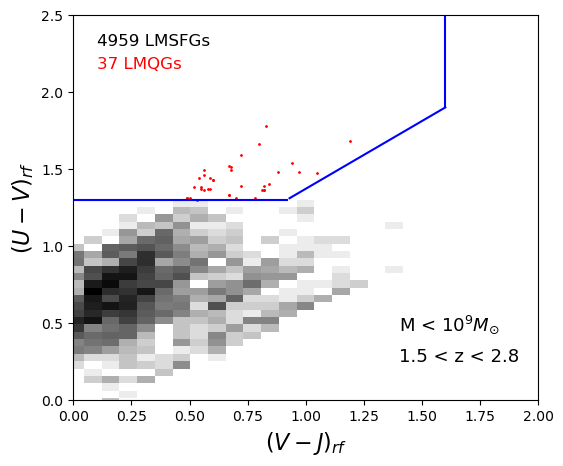

In [39]:
plt.figure(figsize=(6,5))
plt.hist2d(bincn_SFG[:,3],bincn_SFG[:,2],bins=35,norm= mcolors.LogNorm(vmin=None, vmax=None, clip=False),cmap='Greys')
plt.scatter(bincn_QG[:,3],bincn_QG[:,2],s=1,color='red')
plt.xlim(0,2)
plt.ylim(0,2.5)
plt.axhline(y=1.3,xmax=0.46,color='blue')
plt.axvline(x=1.6,ymin=0.76,color='blue')
plt.plot(xcn,ycn,color='blue')
plt.text(1.4,0.45,'M < 10$^9M_{\odot}$',fontsize=13)
plt.text(1.4,0.25,'1.5 < z < 2.8',fontsize=13)
plt.text(0.1,2.3,'4959 LMSFGs',fontsize=12,color='black')
plt.text(0.1,2.15,'37 LMQGs',fontsize=12,color='red')
plt.ylabel('$(U-V)_{rf}$',fontsize = 16)
plt.xlabel('$(V-J)_{rf}$',fontsize = 16)
plt.savefig("UVJ_LMSFGs.jpg",dpi=300,bbox_inches='tight')
plt.show()

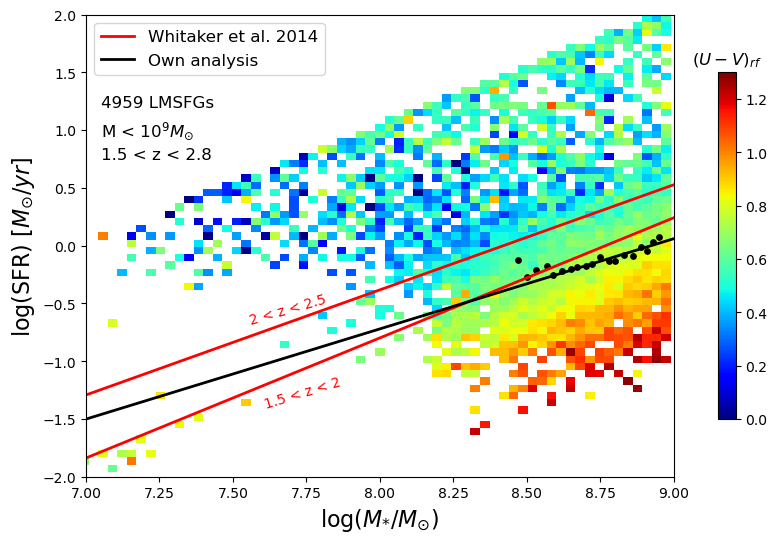

In [40]:
x= np.arange(7,9,0.001)
def pol(x,rango):
    if rango == 1:
        y= 0.99*(x-10.2)+1.31
    elif rango == 2:
        y= 1.04*(x-10.2)+1.49
    elif rango == 3:
        y= 0.91*(x-10.2)+1.62
    elif rango == 4:
        y= 0.197*x-1.440
    return y
plt.figure(figsize=(9.6,6))
plt.plot(x,pol(x,2),linewidth=2,color='red')
plt.plot(x,0.781*x-6.968,linewidth=2,color='black')
plt.plot(x,pol(x,3),linewidth=2,color='red')
plt.legend(['Whitaker et al. 2014','Own analysis'],loc='upper left',prop={'size':12})

sums,ybins,xbins=np.histogram2d(np.log10(bincn_SFG[:,6]),bincn_SFG[:,4],bins=85,weights=bincn_SFG[:,2])
counts,_,_=np.histogram2d(np.log10(bincn_SFG[:,6]),bincn_SFG[:,4],bins=85)
with np.errstate(divide='ignore',invalid='ignore'):
    img=plt.pcolormesh(xbins,ybins,sums/counts,cmap='jet',vmin=0,vmax=1.3)
cb1= plt.colorbar(img,shrink=0.75,pad=0.06)
cb1.ax.set_title('$(U-V)_{rf}$')

plt.scatter(stdcn_x,stdcn_y,s=15,color='black')
plt.ylabel('log(SFR) $[M_⊙/yr]$',fontsize = 16)
plt.xlabel('log$(M_{*}/M_⊙)$',fontsize = 16)
plt.ylim(-2,2)
plt.xlim(7,9)
plt.text(7.55,-0.68,'2 < z < 2.5',fontsize=10,color='red',rotation=16)
plt.text(7.6,-1.41,'1.5 < z < 2',fontsize=10,color='red',rotation=17)
plt.text(7.05,1.2,'4959 LMSFGs',fontsize=12,color='black')
plt.text(7.05,0.95,'M < 10$^9M_{\odot}$',fontsize=12)
plt.text(7.05,0.75,'1.5 < z < 2.8',fontsize=12)
plt.savefig("MS_LMSFGs.jpg",dpi=300,bbox_inches='tight')
plt.show()

In [41]:
np.savetxt('cn_x',stdcn_x)
np.savetxt('cn_y',stdcn_y)

In [42]:
class_star= np.array([registro[5] for registro in m0_mstellar]) 
zphot= np.array([registro[3] for registro in m0_photoz])        
zspec= np.array([registro[74] for registro in m0_multiwave])   
zbest= best(zphot,zspec)                                        
regis=([27])  
mass= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,3,regis)  
regis=([12,15])  
SFR= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,2,regis)
regis= np.array([25,7,15,21,17])        
flux= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,4,regis)
m= -2.5*np.log10(flux*10**(-6))+8.90   
color= m[:,1]-m[:,2]  
regis= np.array([63])
l= collect(m0_photoz,m0_physical,m0_mstellar,m0_multiwave,m0_photoz2,m0_multiderived,6,regis)   #radio 50% [px]
esc= 0.06     
r= esc*2*l    
kpc_arcmin= cosmo.kpc_proper_per_arcmin(zbest).value 
kpc_arcseg= kpc_arcmin/60   
tam= r[:,0]*kpc_arcseg   
sSFR= SFR/(10**mass)       

T= np.column_stack((class_star,zbest,mass,m[:,0],m[:,4],m[:,3],color,tam,SFR,sSFR))
T= T[T[:,0]<0.7]                         
T= T[T[:,3]<26.5]                        
T= T[T[:,1]<=2.8]                        
T= T[T[:,1]>=1.5]
T= T[T[:,2]<9]                       
T= T[T[:,2]>=0]        
T= T[T[:,9]<5]         
print('Total number of low-mass galaxies in the cosmic noon=',np.shape(T)[(0)])
T5= T[T[:,2]>=6]       #lMGs between 6<log(M)<6.5
T5= T5[T5[:,2]<6.5]
z5= round(stat.mean(T5[:,1]),3)
mV5= round(stat.mean(T5[:,4]),3)
mJ5= round(stat.mean(T5[:,5]),3)
color5= round(stat.mean(T5[:,6]),3)
tam5= round(stat.mean(T5[:,7]),3)
SFR5= round(stat.mean(T5[:,8]),3)
sSFR5= round(stat.mean(np.log10(T5[:,10])),3)
print('Number of LMGs between 6-6.5=',np.shape(T5)[(0)])
print('<z> =',z5)
print('<mV> =',mV5)
print('<mJ> =',mJ5)
print('<color> =',color5)
print('<D50> =',tam5)
print('<SFR> =',SFR5)
print('<log(sSFR)> =',sSFR5)
print('------------------------------------------------------------------------------------------------------')
T6= T[T[:,2]>=6.5]       #lMGs between 6.5<log(M)<7
T6= T6[T6[:,2]<7]
print('Number of LMGs between 6.5-7=',np.shape(T6)[(0)])
z6= round(stat.mean(T6[:,1]),3)
mV6= round(stat.mean(T6[:,4]),3)
mJ6= round(stat.mean(T6[:,5]),3)
color6= round(stat.mean(T6[:,6]),3)
tam6= round(stat.mean(T6[:,7]),3)
SFR6= round(stat.mean(T6[:,8]),3)
sSFR6= round(stat.mean(np.log10(T6[:,10])),3)
print('<z> =',z6)
print('<mV> =',mV6)
print('<mJ> =',mJ6)
print('<color> =',color6)
print('<D50> =',tam6)
print('<SFR> =',SFR6)
print('<log(sSFR)> =',sSFR6)
print('------------------------------------------------------------------------------------------------------')
T1= T[T[:,2]>=7]       #lMGs between 7<log(M)<7.5
T1= T1[T1[:,2]<7.5]
print('Number of LMGs between 7-7.5=',np.shape(T1)[(0)])
z1= round(stat.mean(T1[:,1]),3)
mV1= round(stat.mean(T1[:,4]),3)
mJ1= round(stat.mean(T1[:,5]),3)
color1= round(stat.mean(T1[:,6][~np.isnan(T1[:,6])]),3)
tam1= round(stat.mean(T1[:,7]),3)
SFR1= round(stat.mean(T1[:,8]),3)
sSFR1= round(stat.mean(np.log10(T1[:,10])),3)
print('<z> =',z1)
print('<mV> =',mV1)
print('<mJ> =',mJ1)
print('<color> =',color1)
print('<D50> =',tam1)
print('<SFR> =',SFR1)
print('<log(sSFR)> =',sSFR1)
print('------------------------------------------------------------------------------------------------------')
T2= T[T[:,2]>=7.5]       #lMGs between 7.5<log(M)<8
T2= T2[T2[:,2]<8]
print('Number of LMGs between 7.5-8=',np.shape(T2)[(0)])
z2= round(stat.mean(T2[:,1]),3)
mV2= round(stat.mean(T2[:,4][~np.isnan(T2[:,4])]),3)
mJ2= round(stat.mean(T2[:,5][~np.isnan(T2[:,5])]),3)
color2= round(stat.mean(T2[:,6][~np.isnan(T2[:,6])]),3)
tam2= round(stat.mean(T2[:,7]),3)
SFR2= round(stat.mean(T2[:,8]),3)
sSFR2= round(stat.mean(np.log10(T2[:,10])),3)
print('<z> =',z2)
print('<mV> =',mV2)
print('<mJ> =',mJ2)
print('<color> =',color2)
print('<D50> =',tam2)
print('<SFR> =',SFR2)
print('<log(sSFR)> =',sSFR2)
print('------------------------------------------------------------------------------------------------------')
T3= T[T[:,2]>=8]       #lMGs between 8<log(M)<8.5
T3= T3[T3[:,2]<8.5]
print('Number of LMGs between 8-8.5=',np.shape(T3)[(0)])
z3= round(stat.mean(T3[:,1]),3)
mV3= round(stat.mean(T3[:,4][~np.isnan(T3[:,4])]),3)
mJ3= round(stat.mean(T3[:,5][~np.isnan(T3[:,5])]),3)
color3= round(stat.mean(T3[:,6][~np.isnan(T3[:,6])]),3)
tam3= round(stat.mean(T3[:,7]),3)
SFR3= round(stat.mean(T3[:,8]),3)
sSFR3= round(stat.mean(np.log10(T3[:,10])),3)
print('<z> =',z3)
print('<mV> =',mV3)
print('<mJ> =',mJ3)
print('<color> =',color3)
print('<D50> =',tam3)
print('<SFR> =',SFR3)
print('<log(sSFR)> =',sSFR3)
print('------------------------------------------------------------------------------------------------------')
T4= T[T[:,2]>=8.5]       #lMGs between 8.5<log(M)<9
T4= T4[T4[:,2]<=9]
print('Number of LMGs between 8.5-9=',np.shape(T4)[(0)])
z4= round(stat.mean(T4[:,1]),3)
mV4= round(stat.mean(T4[:,4][~np.isnan(T4[:,4])]),3)
mJ4= round(stat.mean(T4[:,5][~np.isnan(T4[:,5])]),3)
color4= round(stat.mean(T4[:,6][~np.isnan(T4[:,6])]),3)
tam4= round(stat.mean(T4[:,7]),3)
SFR4= round(stat.mean(T4[:,8]),3)
sSFR4= round(stat.mean(np.log10(T4[:,10])),3)
print('<z> =',z4)
print('<mV> =',mV4)
print('<mJ> =',mJ4)
print('<color> =',color4)
print('<D50> =',tam4)
print('<SFR> =',SFR4)
print('<log(sSFR)> =',sSFR4)

C:\Users\mario\AppData\Local\Temp\ipykernel_13628\1718947132.py:11: RuntimeWarning: divide by zero encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90
C:\Users\mario\AppData\Local\Temp\ipykernel_13628\1718947132.py:11: RuntimeWarning: invalid value encountered in log10
  m= -2.5*np.log10(flux*10**(-6))+8.90


Total number of low-mass galaxies in the cosmic noon= 4996
Number of LMGs between 6-6.5= 6
<z> = 2.278
<mV> = 25.948
<mJ> = 25.749
<color> = 0.771
<D50> = 3.537
<SFR> = 0.042
<log(sSFR)> = -8.675
------------------------------------------------------------------------------------------------------
Number of LMGs between 6.5-7= 12
<z> = 2.146
<mV> = 25.894
<mJ> = 25.667
<color> = 0.804
<D50> = 4.859
<SFR> = 0.271
<log(sSFR)> = -7.789
------------------------------------------------------------------------------------------------------
Number of LMGs between 7-7.5= 62
<z> = 2.195
<mV> = 26.267
<mJ> = 25.876
<color> = 0.608
<D50> = 4.27
<SFR> = 1.11
<log(sSFR)> = -7.549
------------------------------------------------------------------------------------------------------
Number of LMGs between 7.5-8= 269
<z> = 2.147
<mV> = 26.516
<mJ> = 26.185
<color> = 0.431
<D50> = 3.938
<SFR> = 3.163
<log(sSFR)> = -7.439
----------------------------------------------------------------------------------